# Auto Parts Demand Forecasting — EDA, Baseline, LightGBM & Blend

Notebook này được sửa theo hướng thi thực tế:

1. Sửa baseline theo **more recent windows** + **Sunday factor**.
2. Tạo bảng **top contribution = weight × RMSSE**.
3. Plot riêng **top 30 SKU gây lỗi lớn**.
4. Viết rule riêng cho **SKU inactive / sparse**.
5. Làm **LightGBM cho top 1000 SKU theo profit weight**.
6. **Blend baseline + LightGBM**.
7. Dùng **rolling validation 2–3 fold**, không tin một split duy nhất.

> Mục tiêu: có pipeline rõ ràng để EDA → validate → cải thiện → tạo submission.

# PHẦN 1 — Setup & đọc dữ liệu

Phần này:
- Import thư viện.
- Khai báo đường dẫn (`data/train.csv` ở root repo, output → `main/output/`).
- Bật/tắt LightGBM.
- Đọc và làm sạch `train.csv`.

In [ ]:
import os
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

RANDOM_STATE = 42
EPS = 1e-9

# =========================
# CONFIG — main/data/ và main/output/ (notebook trong main/src/)
# =========================
def resolve_repo_root() -> Path:
    """Tìm root repo có main/data/train.csv (hoặc data/train.csv legacy)."""
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "main" / "data" / "train.csv").exists():
            return p
        if (p / "data" / "train.csv").exists():
            return p
    raise FileNotFoundError(
        "Không tìm thấy main/data/train.csv. Mở notebook từ main/src/ hoặc chạy Jupyter tại root repo."
    )


def resolve_data_dir(repo_root: Path) -> Path:
    main_data = repo_root / "main" / "data"
    if (main_data / "train.csv").exists():
        return main_data
    return repo_root / "data"


REPO_ROOT = resolve_repo_root()
DATA_DIR = resolve_data_dir(REPO_ROOT)
MAIN_DIR = REPO_ROOT / "main" if (REPO_ROOT / "main").is_dir() else REPO_ROOT
OUTPUT_DIR = MAIN_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train.csv"
SAMPLE_PATH = DATA_DIR / "sample_submission.csv"

# Fallback Colab / mount tạm
if not TRAIN_PATH.exists() and Path("/mnt/data/train.csv").exists():
    TRAIN_PATH = Path("/mnt/data/train.csv")
if not SAMPLE_PATH.exists() and Path("/mnt/data/sample_submission.csv").exists():
    SAMPLE_PATH = Path("/mnt/data/sample_submission.csv")

# LightGBM có thể mất thời gian. Nếu máy yếu, để False trước để chạy baseline.
RUN_LIGHTGBM = True
RUN_LIGHTGBM_ROLLING = True  # bật True nếu muốn train LightGBM trên nhiều rolling folds
TOP_N_SKUS = 2000

# Baseline cải tiến: dùng dữ liệu gần hơn
BASELINE_WINDOWS = (14, 28, 56, 90)
BASELINE_WEIGHTS = (0.40, 0.30, 0.20, 0.10)
SUNDAY_FACTOR_FLOOR = 0.001

print("REPO_ROOT:", REPO_ROOT)
print("TRAIN_PATH:", TRAIN_PATH, "| exists:", TRAIN_PATH.exists())
print("SAMPLE_PATH:", SAMPLE_PATH, "| exists:", SAMPLE_PATH.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
    print("LightGBM is available.")
except Exception as e:
    HAS_LIGHTGBM = False
    print("LightGBM is NOT available.")
    print("Nếu muốn chạy LightGBM, cài bằng: pip install lightgbm")

REPO_ROOT: c:\Homework\Code File\Python Code File\giải cỏ
TRAIN_PATH: c:\Homework\Code File\Python Code File\giải cỏ\data\train.csv | exists: True
SAMPLE_PATH: c:\Homework\Code File\Python Code File\giải cỏ\data\sample_submission.csv | exists: True
OUTPUT_DIR: c:\Homework\Code File\Python Code File\giải cỏ\main\output
LightGBM is NOT available.
Nếu muốn chạy LightGBM, cài bằng: pip install lightgbm


In [24]:
df = pd.read_csv(TRAIN_PATH)
print("Raw shape:", df.shape)
display(df.head())
display(df.dtypes)

Raw shape: (711980, 8)


,Date,Stt,ItemCode,Quantity,UnitPrice,SalesAmount,Unit Cost,Cost Amount
0,2020-11-17,2000004,SKU-08063,12,242700,2184300,"123559,1",1482709
1,2020-11-17,2000003,SKU-09458,600,"131818,1818",79090909,110000,66000000
2,2020-11-18,2000007,SKU-08062,6,230000,940909,101000,606000
3,2020-11-18,2000006,SKU-09458,240,270000,44181818,110000,26400000
4,2020-11-18,2000005,SKU-09458,240,270000,44181818,110000,26400000


Date           object
Stt            object
ItemCode       object
Quantity        int64
UnitPrice      object
SalesAmount     int64
Unit Cost      object
Cost Amount    object
dtype: object

In [25]:
def parse_vn_number(s):
    """
    Chuyển cột số/tiền về numeric an toàn.
    Xử lý được:
    - số đã là int/float
    - chuỗi dùng dấu phẩy thập phân: '123559,1'
    - chuỗi có dấu cách
    """
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")

    x = (
        s.astype(str)
         .str.strip()
         .str.replace(" ", "", regex=False)
         .str.replace(".", "", regex=False)   # phòng trường hợp có dấu ngăn cách nghìn
         .str.replace(",", ".", regex=False)  # đổi dấu phẩy thập phân
         .replace({"nan": np.nan, "None": np.nan, "": np.nan})
    )
    return pd.to_numeric(x, errors="coerce")


# Chuẩn hóa tên cột
df["Date"] = pd.to_datetime(df["Date"])

df = df.rename(columns={
    "Unit Cost": "UnitCost",
    "Cost Amount": "CostAmount"
})

required_cols = ["Date", "Stt", "ItemCode", "Quantity", "UnitPrice", "SalesAmount", "UnitCost", "CostAmount"]
missing_cols = [c for c in required_cols if c not in df.columns]
assert len(missing_cols) == 0, f"Missing columns: {missing_cols}"

# Ép kiểu số
for col in ["Quantity", "UnitPrice", "SalesAmount", "UnitCost", "CostAmount"]:
    df[col] = parse_vn_number(df[col])

print("Missing after parse:")
display(df[["Quantity", "UnitPrice", "SalesAmount", "UnitCost", "CostAmount"]].isna().sum().to_frame("missing_after_parse"))

# Feature nghiệp vụ
df["line_profit"] = df["SalesAmount"] - df["CostAmount"]

# Target demand không âm
# Quantity âm có thể là bảo hành, đổi miễn phí, hàng tặng, chuyển kho, hao hụt...
df["demand_qty"] = df["Quantity"].clip(lower=0)

# Flag EDA
df["is_negative_qty"] = df["Quantity"] < 0
df["is_positive_qty"] = df["Quantity"] > 0
df["is_zero_revenue"] = df["SalesAmount"] == 0
df["is_negative_revenue"] = df["SalesAmount"] < 0
df["is_negative_cost"] = df["CostAmount"] < 0

print("Clean shape:", df.shape)
display(df.head())
display(df.dtypes)

Missing after parse:


,missing_after_parse
Quantity,0
UnitPrice,0
SalesAmount,0
UnitCost,0
CostAmount,0


Clean shape: (711980, 15)


,Date,Stt,ItemCode,Quantity,UnitPrice,SalesAmount,UnitCost,CostAmount,line_profit,demand_qty,is_negative_qty,is_positive_qty,is_zero_revenue,is_negative_revenue,is_negative_cost
0,2020-11-17,2000004,SKU-08063,12,"242,700.000000",2184300,"123,559.100000","1,482,709.000000","701,591.000000",12,False,True,False,False,False
1,2020-11-17,2000003,SKU-09458,600,"131,818.181800",79090909,"110,000.000000","66,000,000.000000","13,090,909.000000",600,False,True,False,False,False
2,2020-11-18,2000007,SKU-08062,6,"230,000.000000",940909,"101,000.000000","606,000.000000","334,909.000000",6,False,True,False,False,False
3,2020-11-18,2000006,SKU-09458,240,"270,000.000000",44181818,"110,000.000000","26,400,000.000000","17,781,818.000000",240,False,True,False,False,False
4,2020-11-18,2000005,SKU-09458,240,"270,000.000000",44181818,"110,000.000000","26,400,000.000000","17,781,818.000000",240,False,True,False,False,False


Date                   datetime64[ns]
Stt                            object
ItemCode                       object
Quantity                        int64
UnitPrice                     float64
SalesAmount                     int64
UnitCost                      float64
CostAmount                    float64
line_profit                   float64
demand_qty                      int64
is_negative_qty                  bool
is_positive_qty                  bool
is_zero_revenue                  bool
is_negative_revenue              bool
is_negative_cost                 bool
dtype: object

# PHẦN 2 — EDA nhanh & hiểu bài toán

Phần này kiểm tra:
- Số dòng, số SKU, khoảng ngày.
- Dữ liệu âm.
- Độ thưa SKU-ngày.
- Weekday effect.

In [26]:
overview = {
    "n_rows": len(df),
    "n_skus": df["ItemCode"].nunique(),
    "min_date": df["Date"].min(),
    "max_date": df["Date"].max(),
    "n_transaction_dates": df["Date"].nunique(),
    "calendar_days": (df["Date"].max() - df["Date"].min()).days + 1,
    "total_quantity_net": df["Quantity"].sum(),
    "total_demand_qty_positive_only": df["demand_qty"].sum(),
    "total_negative_quantity": df.loc[df["Quantity"] < 0, "Quantity"].sum(),
    "n_negative_qty_rows": int((df["Quantity"] < 0).sum()),
    "n_positive_qty_rows": int((df["Quantity"] > 0).sum()),
}
display(pd.Series(overview).to_frame("value"))

print("Duplicate rows:", df.duplicated().sum())

num_cols = ["Quantity", "demand_qty", "UnitPrice", "SalesAmount", "UnitCost", "CostAmount", "line_profit"]
display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

,value
n_rows,711980
n_skus,15972
min_date,2020-11-17 00:00:00
max_date,2025-09-05 00:00:00
n_transaction_dates,1411
calendar_days,1754
total_quantity_net,2447253
total_demand_qty_positive_only,2534091
total_negative_quantity,-86838
n_negative_qty_rows,37434


Duplicate rows: 1473


,count,mean,std,min,1%,5%,50%,95%,99%,max
Quantity,"711,980.000000",3.437250,25.490722,-998.000000,-2.000000,-1.000000,1.000000,10.000000,30.000000,"5,998.000000"
demand_qty,"711,980.000000",3.559217,25.305183,0.000000,0.000000,0.000000,1.000000,10.000000,30.000000,"5,998.000000"
UnitPrice,"711,980.000000","536,172.655003","1,151,269.375674","-30,011,000.000000","-1,200,000.000000","-68,600.000000","285,000.000000","1,750,000.000000","3,450,000.000000","79,627,535.000000"
SalesAmount,"711,980.000000","970,936.600739","3,888,066.625386","-184,240,000.000000","-1,420,000.000000","-110,000.000000","510,000.000000","2,805,000.000000","7,968,000.000000","932,413,092.000000"
UnitCost,"711,980.000000","377,920.829574","665,555.066369","-19,799,019.370000","-893,717.655500","-40,000.000000","202,277.600000","1,334,680.062000","2,464,848.400700","40,500,000.000000"
CostAmount,"711,980.000000","733,517.480438","3,282,585.739951","-166,865,193.000000","-1,100,000.000000","-65,287.550000","366,139.000000","2,187,666.000000","6,057,758.410000","838,717,832.000000"
line_profit,"711,980.000000","237,419.120301","1,181,891.727748","-72,895,386.000000","-596,061.240000","-110,889.450000","125,972.000000","800,791.450000","2,005,899.080000","133,193,972.000000"


In [27]:
neg = df[df["Quantity"] < 0].copy()

neg_patterns = pd.DataFrame({
    "condition": [
        "Quantity < 0",
        "Quantity < 0 & SalesAmount < 0 & CostAmount < 0",
        "Quantity < 0 & SalesAmount == 0",
        "Quantity < 0 & SalesAmount < 0",
        "Quantity < 0 & CostAmount < 0",
        "Quantity < 0 & line_profit <= 0",
        "Quantity < 0 & line_profit > 0",
    ],
    "n_rows": [
        (df["Quantity"] < 0).sum(),
        ((df["Quantity"] < 0) & (df["SalesAmount"] < 0) & (df["CostAmount"] < 0)).sum(),
        ((df["Quantity"] < 0) & (df["SalesAmount"] == 0)).sum(),
        ((df["Quantity"] < 0) & (df["SalesAmount"] < 0)).sum(),
        ((df["Quantity"] < 0) & (df["CostAmount"] < 0)).sum(),
        ((df["Quantity"] < 0) & (df["line_profit"] <= 0)).sum(),
        ((df["Quantity"] < 0) & (df["line_profit"] > 0)).sum(),
    ]
})
display(neg_patterns)

neg_sku = (
    neg.groupby("ItemCode")
       .agg(
           neg_rows=("Quantity", "size"),
           neg_qty=("Quantity", "sum"),
           neg_sales=("SalesAmount", "sum"),
           neg_cost=("CostAmount", "sum"),
           neg_profit=("line_profit", "sum")
       )
       .sort_values("neg_rows", ascending=False)
)
display(neg_sku.head(20))

,condition,n_rows
0,Quantity < 0,37434
1,Quantity < 0 & SalesAmount < 0 & CostAmount < 0,37279
2,Quantity < 0 & SalesAmount == 0,119
3,Quantity < 0 & SalesAmount < 0,37315
4,Quantity < 0 & CostAmount < 0,37393
5,Quantity < 0 & line_profit <= 0,36137
6,Quantity < 0 & line_profit > 0,1297


,neg_rows,neg_qty,neg_sales,neg_cost,neg_profit
ItemCode,,,,,
SKU-15599,97,-229,-32898820,"-23,499,154.510000","-9,399,665.490000"
SKU-15146,96,-184,-29871220,"-21,255,992.080000","-8,615,227.920000"
SKU-14323,94,-265,-65620464,"-50,066,803.500000","-15,553,660.500000"
SKU-00324,87,-90,-115109296,"-89,257,481.000000","-25,851,815.000000"
SKU-15145,86,-268,-32686755,"-22,890,808.690000","-9,795,946.310000"
SKU-14806,81,-148,-31896315,"-23,818,482.600000","-8,077,832.400000"
SKU-14320,78,-195,-46193432,"-33,167,697.590000","-13,025,734.410000"
SKU-12064,77,-133,-128329222,"-65,156,458.120000","-63,172,763.880000"
SKU-09510,77,-377,-41492724,"-31,638,754.090000","-9,853,969.910000"


In [28]:
# Aggregate transaction line -> SKU-day
daily = (
    df.groupby(["ItemCode", "Date"], as_index=False)
      .agg(
          y=("demand_qty", "sum"),
          net_qty=("Quantity", "sum"),
          sales=("SalesAmount", "sum"),
          cost=("CostAmount", "sum"),
          profit=("line_profit", "sum"),
          n_lines=("Stt", "size")
      )
)

daily["is_positive_day"] = daily["y"] > 0

n_skus = df["ItemCode"].nunique()
all_dates = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
n_calendar_days = len(all_dates)

possible_sku_days = n_skus * n_calendar_days
observed_sku_days = daily[["ItemCode", "Date"]].drop_duplicates().shape[0]
positive_sku_days = daily.loc[daily["y"] > 0, ["ItemCode", "Date"]].drop_duplicates().shape[0]

density_info = {
    "n_skus": n_skus,
    "n_calendar_days": n_calendar_days,
    "possible_sku_days": possible_sku_days,
    "observed_sku_days_in_transactions": observed_sku_days,
    "positive_sku_days": positive_sku_days,
    "positive_density": positive_sku_days / possible_sku_days,
}
display(pd.Series(density_info).to_frame("value"))
display(daily.head())

,value
n_skus,"15,972.000000"
n_calendar_days,"1,754.000000"
possible_sku_days,"28,014,888.000000"
observed_sku_days_in_transactions,"507,050.000000"
positive_sku_days,"485,454.000000"
positive_density,0.017328


,ItemCode,Date,y,net_qty,sales,cost,profit,n_lines,is_positive_day
0,SKU-00001,2025-05-26,1,1,830368,0.000000,"830,368.000000",1,True
1,SKU-00001,2025-05-27,1,1,1032840,0.000000,"1,032,840.000000",1,True
2,SKU-00001,2025-05-28,2,2,2084484,0.000000,"2,084,484.000000",2,True
3,SKU-00001,2025-05-30,2,2,1414600,0.000000,"1,414,600.000000",2,True
4,SKU-00001,2025-06-04,6,6,4138320,0.000000,"4,138,320.000000",6,True


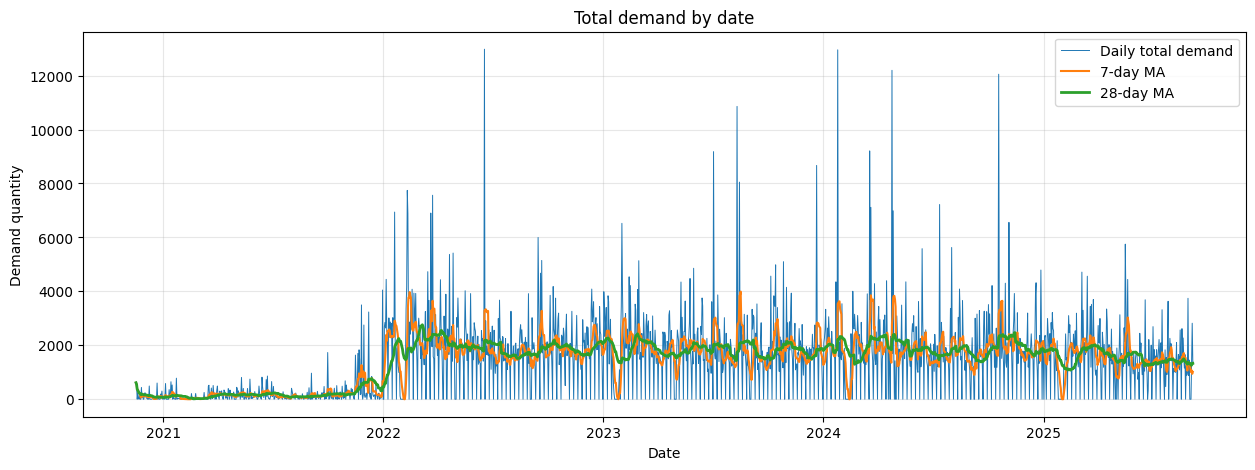

,mean_y,median_y,max_y,mean_active_skus,n_days
day_name,,,,,
Monday,"1,816.712000","1,866.500000","9,208.000000",371.360000,250
Tuesday,"1,688.171315","1,727.000000","8,050.000000",351.513944,251
Wednesday,"1,769.378486","1,686.000000","12,196.000000",338.119522,251
Thursday,"1,777.840637","1,698.000000","12,956.000000",330.697211,251
Friday,"1,764.944223","1,660.000000","12,051.000000",331.171315,251
Saturday,"1,289.036000","1,395.500000","12,979.000000",299.860000,250
Sunday,2.280000,0.000000,506.000000,0.072000,250


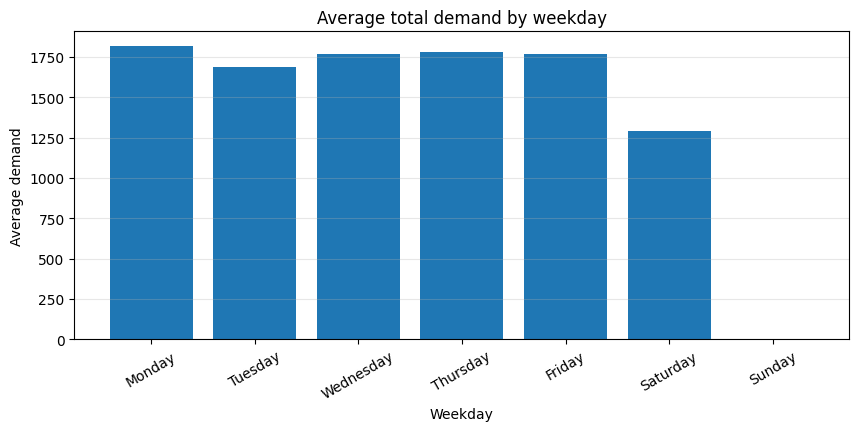

In [29]:
daily_total = (
    daily.groupby("Date", as_index=False)
         .agg(
             total_y=("y", "sum"),
             total_net_qty=("net_qty", "sum"),
             total_sales=("sales", "sum"),
             total_profit=("profit", "sum"),
             active_skus=("ItemCode", "nunique"),
             n_lines=("n_lines", "sum")
         )
)

daily_total = (
    pd.DataFrame({"Date": all_dates})
    .merge(daily_total, on="Date", how="left")
    .fillna({
        "total_y": 0,
        "total_net_qty": 0,
        "total_sales": 0,
        "total_profit": 0,
        "active_skus": 0,
        "n_lines": 0
    })
)

daily_total["dow"] = daily_total["Date"].dt.dayofweek
daily_total["day_name"] = daily_total["Date"].dt.day_name()
daily_total["month"] = daily_total["Date"].dt.month
daily_total["year"] = daily_total["Date"].dt.year
daily_total["y_7d_ma"] = daily_total["total_y"].rolling(7, min_periods=1).mean()
daily_total["y_28d_ma"] = daily_total["total_y"].rolling(28, min_periods=1).mean()

plt.figure(figsize=(15, 5))
plt.plot(daily_total["Date"], daily_total["total_y"], linewidth=0.7, label="Daily total demand")
plt.plot(daily_total["Date"], daily_total["y_7d_ma"], linewidth=1.5, label="7-day MA")
plt.plot(daily_total["Date"], daily_total["y_28d_ma"], linewidth=2, label="28-day MA")
plt.title("Total demand by date")
plt.xlabel("Date")
plt.ylabel("Demand quantity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_stats = (
    daily_total.groupby("day_name")
    .agg(
        mean_y=("total_y", "mean"),
        median_y=("total_y", "median"),
        max_y=("total_y", "max"),
        mean_active_skus=("active_skus", "mean"),
        n_days=("Date", "size")
    )
    .reindex(weekday_order)
)
display(weekday_stats)

plt.figure(figsize=(10, 4))
plt.bar(weekday_stats.index, weekday_stats["mean_y"])
plt.title("Average total demand by weekday")
plt.xlabel("Weekday")
plt.ylabel("Average demand")
plt.xticks(rotation=30)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# PHẦN 3 — Metric WRMSSE, profit weight & validation functions

Phần này tạo các hàm dùng xuyên suốt notebook:
- Aggregate daily demand.
- Tính profit weight.
- Tính scale RMSSE.
- Tính WRMSSE.
- Tạo actual validation matrix.

In [30]:
def aggregate_daily_y(transactions, value_col="demand_qty"):
    return (
        transactions.groupby(["ItemCode", "Date"], as_index=False)[value_col]
        .sum()
        .rename(columns={value_col: "y"})
    )


def compute_sku_weights(transactions):
    tmp = transactions.copy()
    if "line_profit" not in tmp.columns:
        tmp["line_profit"] = tmp["SalesAmount"] - tmp["CostAmount"]

    w = (
        tmp.groupby("ItemCode")["line_profit"]
           .sum()
           .rename("profit")
           .reset_index()
    )
    w["profit_pos"] = w["profit"].clip(lower=0)
    total = w["profit_pos"].sum()
    w["weight"] = np.where(total > 0, w["profit_pos"] / total, 0)
    return w[["ItemCode", "profit", "profit_pos", "weight"]]


def compute_rmsse_scale(train_daily_sparse, sku_list, train_dates):
    date_to_idx = pd.Series(np.arange(len(train_dates)), index=train_dates)
    grouped = dict(tuple(train_daily_sparse.groupby("ItemCode")))
    result = []

    for sku in sku_list:
        arr = np.zeros(len(train_dates), dtype=np.float32)
        if sku in grouped:
            g = grouped[sku]
            idx = date_to_idx.loc[g["Date"]].to_numpy()
            arr[idx] = g["y"].to_numpy(dtype=np.float32)

        if len(arr) <= 1:
            scale = EPS
        else:
            diffs = np.diff(arr)
            scale = float(np.mean(diffs ** 2))
            if scale <= 0:
                scale = EPS
        result.append((sku, scale))

    return pd.DataFrame(result, columns=["ItemCode", "scale"])


def make_actual_matrix_long(daily_sparse, sku_list, dates, value_col="y"):
    idx = pd.MultiIndex.from_product([sku_list, dates], names=["ItemCode", "Date"])
    s = daily_sparse.set_index(["ItemCode", "Date"])[value_col]
    out = s.reindex(idx, fill_value=0).reset_index()
    out = out.rename(columns={value_col: "actual"})
    return out


def wrmsse_score(actual_long, pred_long, scale_df, weight_df):
    eval_df = (
        actual_long.merge(pred_long, on=["ItemCode", "Date"], how="left")
                   .merge(scale_df, on="ItemCode", how="left")
                   .merge(weight_df[["ItemCode", "weight"]], on="ItemCode", how="left")
    )

    eval_df["pred"] = eval_df["pred"].fillna(0).clip(lower=0)
    eval_df["actual"] = eval_df["actual"].fillna(0)
    eval_df["scale"] = eval_df["scale"].fillna(EPS).clip(lower=EPS)
    eval_df["weight"] = eval_df["weight"].fillna(0)
    eval_df["se"] = (eval_df["actual"] - eval_df["pred"]) ** 2

    sku_eval = (
        eval_df.groupby("ItemCode")
        .agg(
            mse=("se", "mean"),
            scale=("scale", "first"),
            weight=("weight", "first"),
            actual_sum=("actual", "sum"),
            pred_sum=("pred", "sum")
        )
        .reset_index()
    )

    sku_eval["rmsse"] = np.sqrt(sku_eval["mse"] / sku_eval["scale"])
    sku_eval["contribution"] = sku_eval["weight"] * sku_eval["rmsse"]
    score = float(sku_eval["contribution"].sum())

    return score, sku_eval, eval_df

,top_k,cum_weight
0,10,0.210903
1,50,0.322472
2,100,0.398178
3,200,0.490764
4,500,0.633820
5,1000,0.747270
6,2000,0.851769
7,5000,0.957478
8,15972,1.000000


,ItemCode,profit,profit_pos,weight,rank,cum_weight
0,SKU-00003,"16,700,681,088.000000","16,700,681,088.000000",0.096986,1,0.096986
1,SKU-00002,"8,012,686,409.000000","8,012,686,409.000000",0.046532,2,0.143518
2,SKU-09458,"2,641,120,895.490000","2,641,120,895.490000",0.015338,3,0.158856
3,SKU-00005,"2,243,340,437.000000","2,243,340,437.000000",0.013028,4,0.171883
4,SKU-08589,"1,285,705,360.510000","1,285,705,360.510000",0.007466,5,0.179350
5,SKU-12534,"1,215,803,793.000000","1,215,803,793.000000",0.007061,6,0.186410
6,SKU-09760,"1,195,313,057.000000","1,195,313,057.000000",0.006942,7,0.193352
7,SKU-12537,"1,106,799,793.000000","1,106,799,793.000000",0.006428,8,0.199780
8,SKU-00324,"978,374,716.170000","978,374,716.170000",0.005682,9,0.205461
9,SKU-14323,"937,104,039.810000","937,104,039.810000",0.005442,10,0.210903


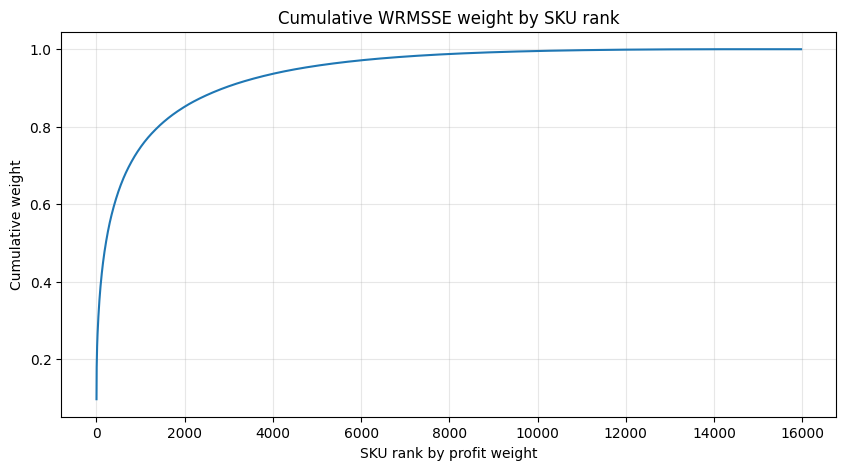

In [31]:
sku_list = sorted(df["ItemCode"].unique())
full_weight_df = compute_sku_weights(df)

weight_sorted = full_weight_df.sort_values("weight", ascending=False).reset_index(drop=True)
weight_sorted["rank"] = np.arange(1, len(weight_sorted) + 1)
weight_sorted["cum_weight"] = weight_sorted["weight"].cumsum()

top_ks = [10, 50, 100, 200, 500, 1000, 2000, 5000, len(weight_sorted)]
top_weight_table = pd.DataFrame({
    "top_k": top_ks,
    "cum_weight": [weight_sorted.loc[:k-1, "weight"].sum() for k in top_ks]
})

display(top_weight_table)
display(weight_sorted.head(30))

plt.figure(figsize=(10, 5))
plt.plot(weight_sorted["rank"], weight_sorted["cum_weight"])
plt.title("Cumulative WRMSSE weight by SKU rank")
plt.xlabel("SKU rank by profit weight")
plt.ylabel("Cumulative weight")
plt.grid(True, alpha=0.3)
plt.show()

# PHẦN 4 — Baseline cải tiến

Baseline mới gồm:
- More recent windows: `14/28/56/90` thay vì `28/56/90/180`.
- Sunday factor floor rất thấp: `0.001`.
- Rule giảm dự báo cho SKU sparse.
- Rule giảm dự báo cho SKU inactive.
- Option set SKU weight = 0 về 0.

In [32]:
def build_baseline_forecast(
    transactions,
    forecast_dates,
    sku_list,
    windows=BASELINE_WINDOWS,
    window_weights=BASELINE_WEIGHTS,
    sunday_floor=SUNDAY_FACTOR_FLOOR,
    sparse_penalty=True,
    weight_df=None,
    zero_weight_to_zero=True,
    sparse_rules=None,
    recency_rules=None
):
    assert len(windows) == len(window_weights)

    transactions = transactions.copy()
    train_end = transactions["Date"].max()
    train_start = transactions["Date"].min()
    daily_sparse = aggregate_daily_y(transactions)

    all_sku = pd.DataFrame({"ItemCode": sku_list})

    # Positive-day stats: chỉ tính ngày y > 0
    pos_daily = daily_sparse[daily_sparse["y"] > 0].copy()
    sku_stats = (
        pos_daily.groupby("ItemCode")
        .agg(
            total_y_pos=("y", "sum"),
            positive_days=("Date", "nunique"),
            last_positive_date=("Date", "max")
        )
        .reset_index()
    )

    sku_stats = all_sku.merge(sku_stats, on="ItemCode", how="left")
    sku_stats["total_y_pos"] = sku_stats["total_y_pos"].fillna(0)
    sku_stats["positive_days"] = sku_stats["positive_days"].fillna(0)
    sku_stats["last_positive_date"] = pd.to_datetime(sku_stats["last_positive_date"])
    sku_stats["days_since_last_sale"] = (train_end - sku_stats["last_positive_date"]).dt.days
    sku_stats["days_since_last_sale"] = sku_stats["days_since_last_sale"].fillna(9999)

    # Rolling window averages per SKU, chia cho số ngày window để tính cả zero days
    base = all_sku.copy()
    for w in windows:
        start = train_end - pd.Timedelta(days=w-1)
        tmp = (
            daily_sparse[(daily_sparse["Date"] >= start) & (daily_sparse["Date"] <= train_end)]
            .groupby("ItemCode")["y"].sum()
            .rename(f"sum_{w}")
            .reset_index()
        )
        base = base.merge(tmp, on="ItemCode", how="left")
        base[f"sum_{w}"] = base[f"sum_{w}"].fillna(0)
        base[f"mean_{w}"] = base[f"sum_{w}"] / w

    base["base_pred"] = 0.0
    for w, ww in zip(windows, window_weights):
        base["base_pred"] += ww * base[f"mean_{w}"]

    base = base.merge(
        sku_stats[["ItemCode", "positive_days", "days_since_last_sale"]],
        on="ItemCode",
        how="left"
    )

    # Sparse rule
    if sparse_rules is None:
        sparse_rules = [
            (1, 0.02),
            (3, 0.10),
            (7, 0.25),
            (14, 0.55),
            (28, 0.75),
        ]

    # Recency rule
    if recency_rules is None:
        recency_rules = [
            (365, 0.00),
            (180, 0.20),
            (90, 0.50),
            (60, 0.70),
        ]

    if sparse_penalty:
        base["sparse_factor"] = 1.0
        for max_days, factor in sparse_rules:
            base.loc[base["positive_days"] <= max_days, "sparse_factor"] = factor

        base["recency_factor"] = 1.0
        # apply from shorter to longer carefully by overriding longer thresholds
        for min_days, factor in recency_rules:
            base.loc[base["days_since_last_sale"] > min_days, "recency_factor"] = factor

        base["base_pred"] = base["base_pred"] * base["sparse_factor"] * base["recency_factor"]

    if weight_df is not None:
        base = base.merge(weight_df[["ItemCode", "weight"]], on="ItemCode", how="left")
        base["weight"] = base["weight"].fillna(0)
        if zero_weight_to_zero:
            base.loc[base["weight"] <= 0, "base_pred"] = 0.0

    # Global weekday factor
    total_daily = daily_sparse.groupby("Date", as_index=False)["y"].sum()
    all_train_dates = pd.DataFrame({"Date": pd.date_range(train_start, train_end, freq="D")})
    total_daily = all_train_dates.merge(total_daily, on="Date", how="left").fillna({"y": 0})
    total_daily["dow"] = total_daily["Date"].dt.dayofweek

    weekday_mean = total_daily.groupby("dow")["y"].mean()
    global_mean = total_daily["y"].mean()
    weekday_factor = (weekday_mean / max(global_mean, EPS)).clip(lower=0.0, upper=2.0).to_dict()

    # Chủ nhật: dùng floor rất thấp để tránh dự báo Chủ nhật quá cao
    weekday_factor[6] = max(float(weekday_factor.get(6, sunday_floor)), sunday_floor)

    # Cross join SKU x forecast_dates
    fdates = pd.DataFrame({"Date": forecast_dates})
    fdates["dow"] = fdates["Date"].dt.dayofweek
    fdates["weekday_factor"] = fdates["dow"].map(weekday_factor).fillna(1.0)

    pred = base[["ItemCode", "base_pred"]].merge(fdates, how="cross")
    pred["pred"] = pred["base_pred"] * pred["weekday_factor"]
    pred["pred"] = pred["pred"].clip(lower=0)

    return pred[["ItemCode", "Date", "pred"]], base, weekday_factor

# PHẦN 5 — Single-fold validation + top contribution

Phần này dùng 56 ngày cuối train làm validation nội bộ:
- Train: từ đầu đến trước 56 ngày cuối.
- Valid: 56 ngày cuối.

Sau đó tạo bảng:
```text
contribution = weight × RMSSE
```

Đây là bảng quan trọng nhất để biết SKU nào đang kéo điểm.

In [33]:
def make_single_validation_split(transactions, horizon=56):
    max_date = transactions["Date"].max()
    valid_start = max_date - pd.Timedelta(days=horizon - 1)
    valid_end = max_date
    train_part = transactions[transactions["Date"] < valid_start].copy()
    valid_part = transactions[(transactions["Date"] >= valid_start) & (transactions["Date"] <= valid_end)].copy()
    valid_dates = pd.date_range(valid_start, valid_end, freq="D")
    return train_part, valid_part, valid_dates, valid_start, valid_end


H = 56
train_part, valid_part, valid_dates, valid_start, valid_end = make_single_validation_split(df, horizon=H)

print("Train:", train_part["Date"].min(), "->", train_part["Date"].max(), train_part.shape)
print("Valid:", valid_start, "->", valid_end, valid_part.shape)

train_daily_part = aggregate_daily_y(train_part)
valid_daily_part = aggregate_daily_y(valid_part)
weight_part = compute_sku_weights(train_part)

train_dates = pd.date_range(train_part["Date"].min(), train_part["Date"].max(), freq="D")
scale_part = compute_rmsse_scale(train_daily_part, sku_list, train_dates)
actual_valid_long = make_actual_matrix_long(valid_daily_part, sku_list, valid_dates)

baseline_valid_pred, baseline_base_table, weekday_factor = build_baseline_forecast(
    train_part,
    valid_dates,
    sku_list,
    windows=BASELINE_WINDOWS,
    window_weights=BASELINE_WEIGHTS,
    sunday_floor=SUNDAY_FACTOR_FLOOR,
    weight_df=weight_part,
    zero_weight_to_zero=True
)

baseline_score, baseline_sku_eval, baseline_eval_df = wrmsse_score(
    actual_valid_long,
    baseline_valid_pred,
    scale_part,
    weight_part
)

print("Improved baseline WRMSSE:", baseline_score)
print("Weekday factor:", weekday_factor)
display(baseline_sku_eval.sort_values("contribution", ascending=False).head(30))

Train: 2020-11-17 00:00:00 -> 2025-07-11 00:00:00 (689708, 15)
Valid: 2025-07-12 00:00:00 -> 2025-09-05 00:00:00 (22272, 15)
Improved baseline WRMSSE: 0.5746122582513302
Weekday factor: {0: 1.2628648439267665, 1: 1.1790346648599557, 2: 1.2217784454796707, 3: 1.2275581665305442, 4: 1.2239589895259175, 5: 0.8796556850364857, 6: 0.0016271787464612107}


,ItemCode,mse,scale,weight,actual_sum,pred_sum,rmsse,contribution
2,SKU-00003,86.712316,56.281673,0.095070,628,555.955688,1.241243,0.118005
1,SKU-00002,32.453180,22.822039,0.045248,324,442.079679,1.192481,0.053957
13993,SKU-14323,"5,199.134136","1,514.133179",0.005414,1345,798.620197,1.853034,0.010032
15241,SKU-15599,"17,893.844710","3,151.594482",0.002707,1479,321.149445,2.382795,0.006450
13990,SKU-14320,"2,104.646793","1,638.200317",0.005120,960,548.741541,1.133460,0.005803
10248,SKU-10532,143.820342,70.894516,0.002977,90,173.788071,1.424308,0.004241
11100,SKU-11398,"1,717.625000",47.499115,0.000676,721,0.000000,6.013418,0.004062
6593,SKU-06772,184.826316,6.263995,0.000679,173,93.597328,5.431955,0.003687
8616,SKU-08863,"1,599.849663","1,716.842651",0.003742,589,479.669645,0.965327,0.003613
9839,SKU-10117,"1,804.225807",302.230988,0.001124,529,203.608615,2.443295,0.002745


,ItemCode,mse,scale,weight,actual_sum,pred_sum,rmsse,contribution,rank_contribution,cum_contribution,contribution_share,cum_contribution_share
0,SKU-00003,86.712316,56.281673,0.095070,628,555.955688,1.241243,0.118005,1,0.118005,0.205364,0.205364
1,SKU-00002,32.453180,22.822039,0.045248,324,442.079679,1.192481,0.053957,2,0.171962,0.093902,0.299266
2,SKU-14323,"5,199.134136","1,514.133179",0.005414,1345,798.620197,1.853034,0.010032,3,0.181994,0.017459,0.316725
3,SKU-15599,"17,893.844710","3,151.594482",0.002707,1479,321.149445,2.382795,0.006450,4,0.188445,0.011226,0.327951
4,SKU-14320,"2,104.646793","1,638.200317",0.005120,960,548.741541,1.133460,0.005803,5,0.194248,0.010099,0.338050
5,SKU-10532,143.820342,70.894516,0.002977,90,173.788071,1.424308,0.004241,6,0.198488,0.007380,0.345430
6,SKU-11398,"1,717.625000",47.499115,0.000676,721,0.000000,6.013418,0.004062,7,0.202550,0.007069,0.352499
7,SKU-06772,184.826316,6.263995,0.000679,173,93.597328,5.431955,0.003687,8,0.206237,0.006416,0.358915
8,SKU-08863,"1,599.849663","1,716.842651",0.003742,589,479.669645,0.965327,0.003613,9,0.209849,0.006287,0.365202
9,SKU-10117,"1,804.225807",302.230988,0.001124,529,203.608615,2.443295,0.002745,10,0.212594,0.004777,0.369979


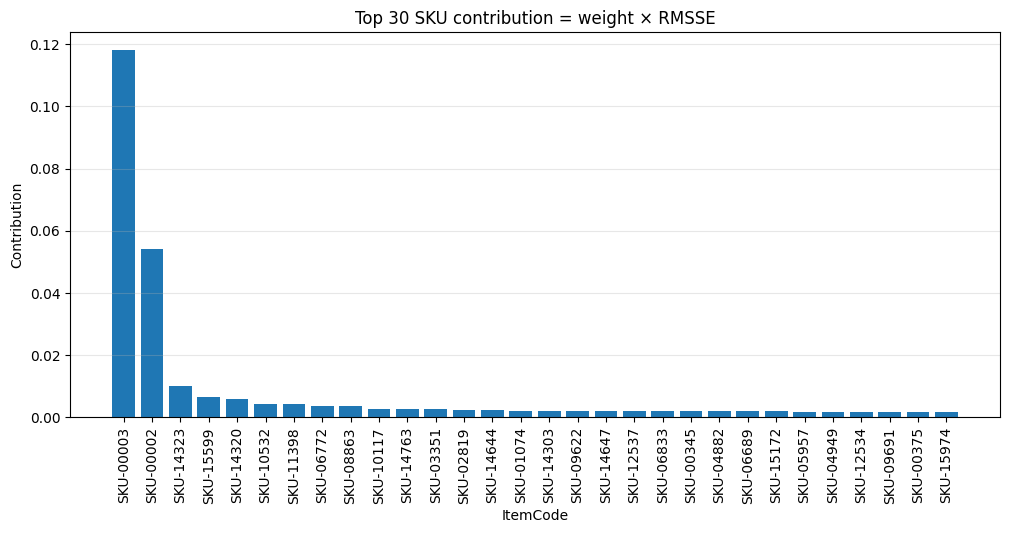

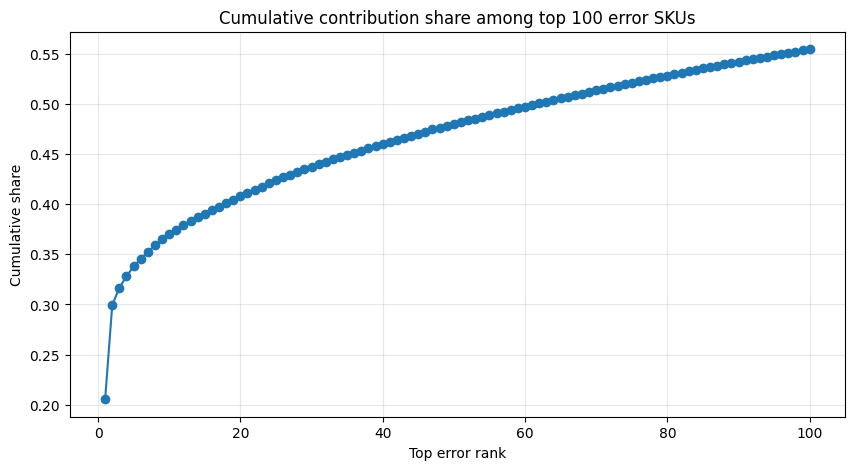

In [34]:
def build_top_contribution_table(sku_eval, top_n=100):
    out = sku_eval.copy()
    out = out.sort_values("contribution", ascending=False).reset_index(drop=True)
    out["rank_contribution"] = np.arange(1, len(out) + 1)
    out["cum_contribution"] = out["contribution"].cumsum()
    total = out["contribution"].sum()
    out["contribution_share"] = np.where(total > 0, out["contribution"] / total, 0)
    out["cum_contribution_share"] = out["contribution_share"].cumsum()
    return out.head(top_n)

top_contrib = build_top_contribution_table(baseline_sku_eval, top_n=100)
display(top_contrib.head(30))

plt.figure(figsize=(12, 5))
plt.bar(top_contrib.head(30)["ItemCode"], top_contrib.head(30)["contribution"])
plt.title("Top 30 SKU contribution = weight × RMSSE")
plt.xlabel("ItemCode")
plt.ylabel("Contribution")
plt.xticks(rotation=90)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(top_contrib)+1), top_contrib["cum_contribution_share"], marker="o")
plt.title("Cumulative contribution share among top 100 error SKUs")
plt.xlabel("Top error rank")
plt.ylabel("Cumulative share")
plt.grid(True, alpha=0.3)
plt.show()

# PHẦN 6 — Plot riêng top 30 SKU gây lỗi lớn

Phần này plot actual vs prediction trong validation cho top 30 SKU có contribution cao nhất.
Dùng để xem SKU bị:
- Over-predict.
- Under-predict.
- Lệch trend.
- Lỗi do ngày Chủ nhật/cuối tuần.

['SKU-00003', 'SKU-00002', 'SKU-14323', 'SKU-15599', 'SKU-14320', 'SKU-10532', 'SKU-11398', 'SKU-06772', 'SKU-08863', 'SKU-10117', 'SKU-14763', 'SKU-03351', 'SKU-02819', 'SKU-14644', 'SKU-01074', 'SKU-14303', 'SKU-09622', 'SKU-14647', 'SKU-12537', 'SKU-06833', 'SKU-00345', 'SKU-04882', 'SKU-06689', 'SKU-15172', 'SKU-05957', 'SKU-04949', 'SKU-12534', 'SKU-09691', 'SKU-00375', 'SKU-15974']


,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
2,SKU-00003,0.095070,1.241243,0.118005,628,555.955688


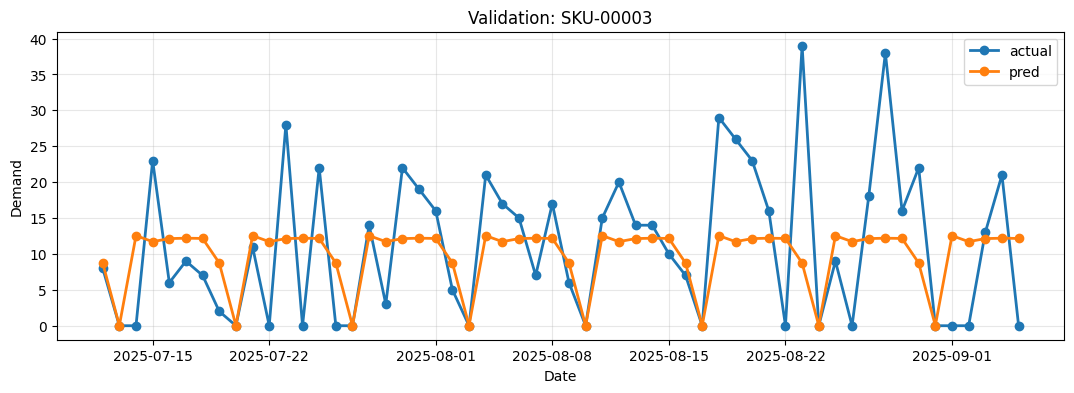

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
1,SKU-00002,0.045248,1.192481,0.053957,324,442.079679


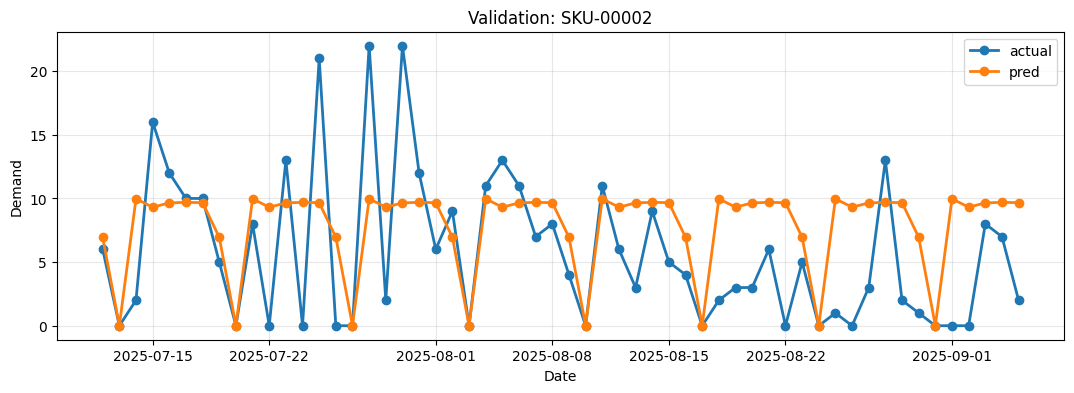

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
13993,SKU-14323,0.005414,1.853034,0.010032,1345,798.620197


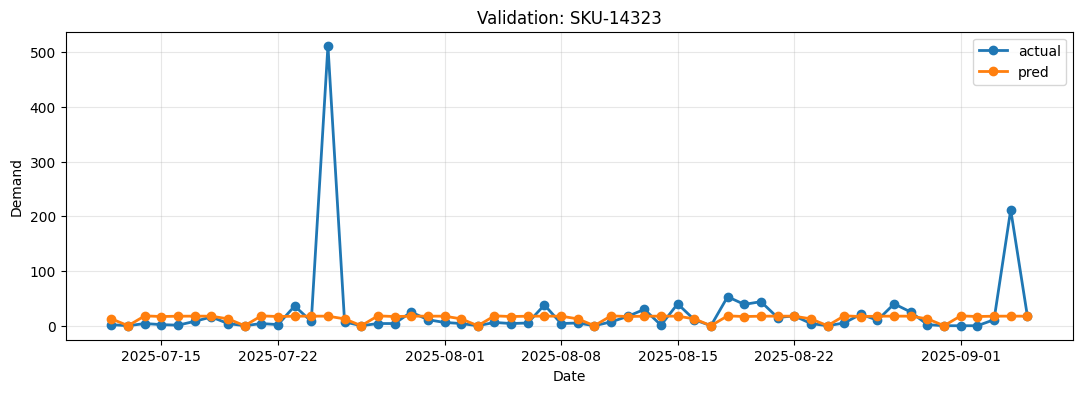

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
15241,SKU-15599,0.002707,2.382795,0.006450,1479,321.149445


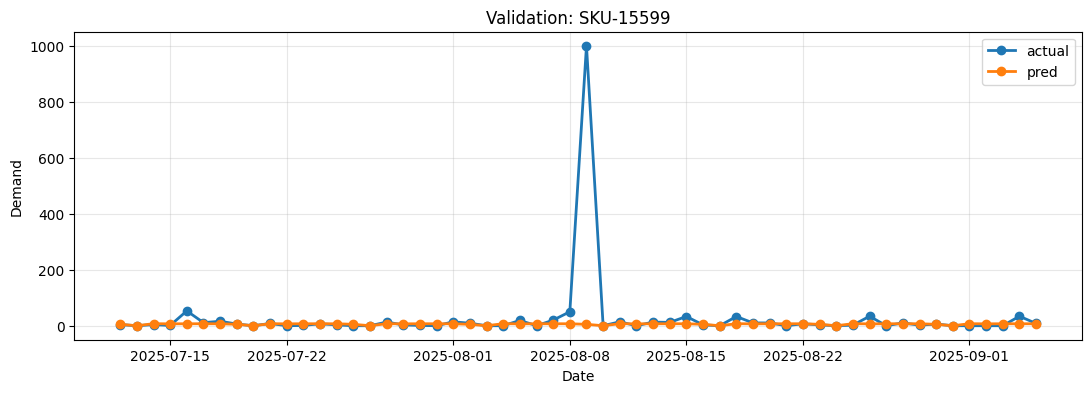

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
13990,SKU-14320,0.005120,1.133460,0.005803,960,548.741541


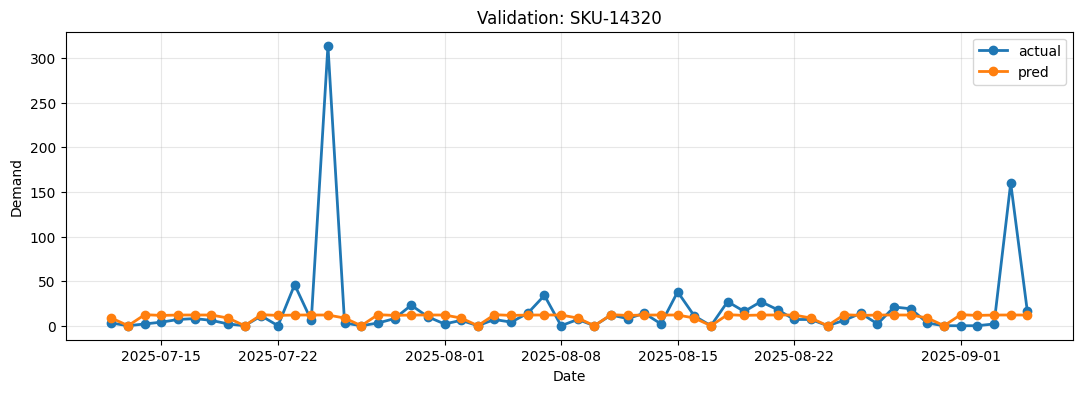

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
10248,SKU-10532,0.002977,1.424308,0.004241,90,173.788071


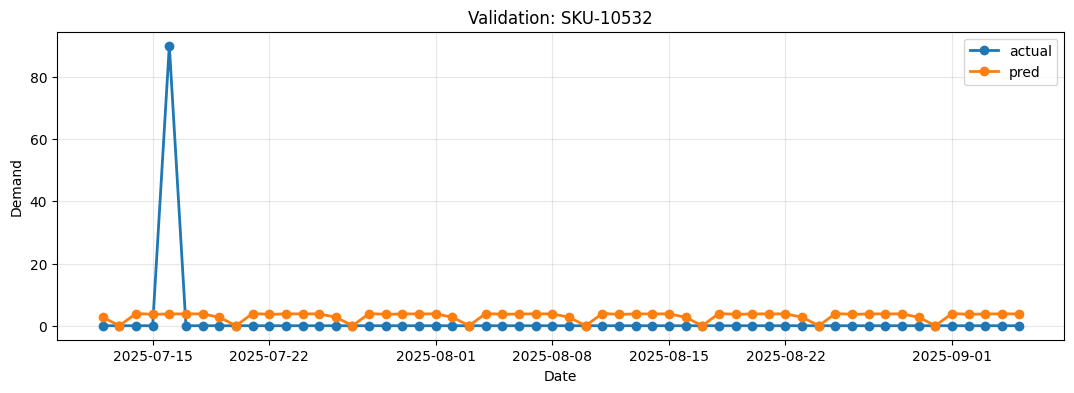

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
11100,SKU-11398,0.000676,6.013418,0.004062,721,0.000000


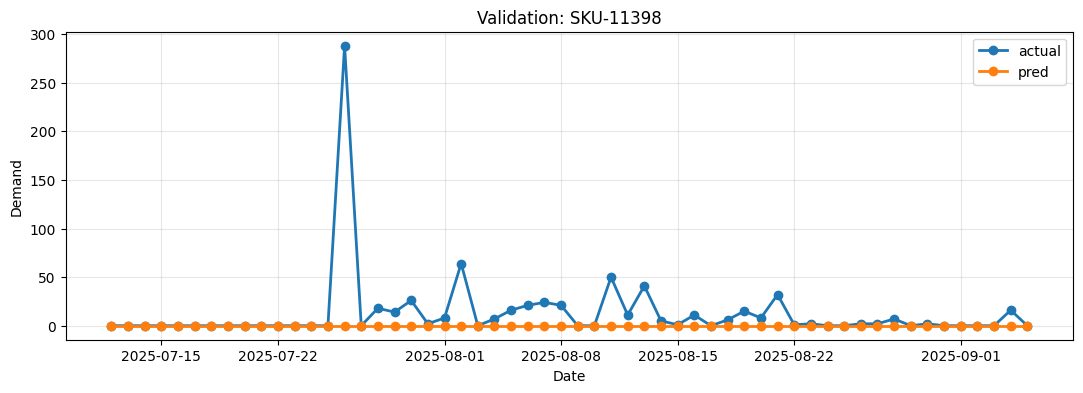

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
6593,SKU-06772,0.000679,5.431955,0.003687,173,93.597328


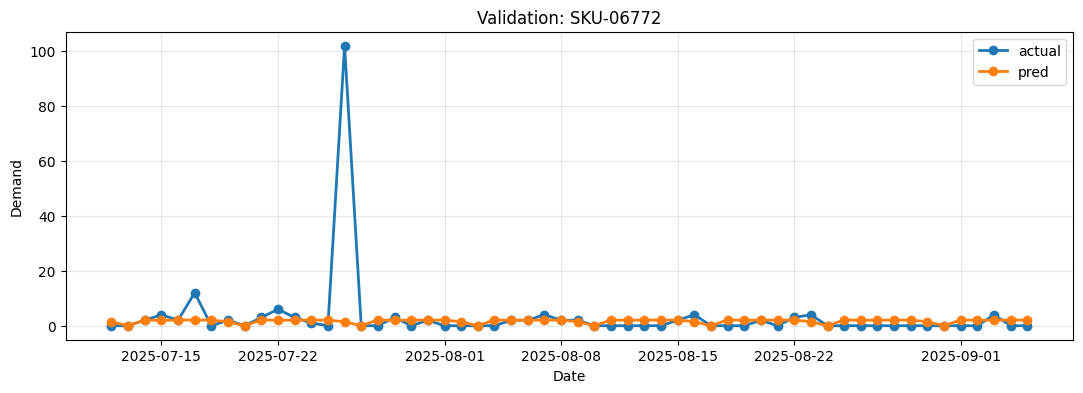

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
8616,SKU-08863,0.003742,0.965327,0.003613,589,479.669645


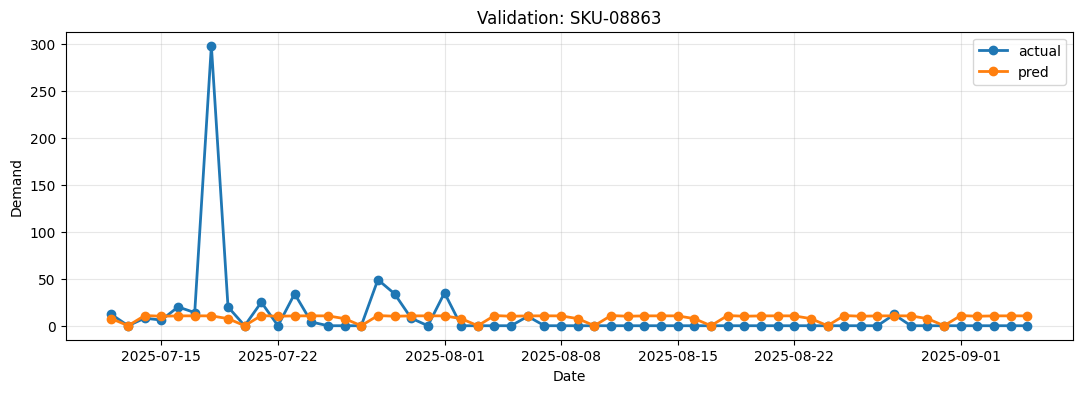

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
9839,SKU-10117,0.001124,2.443295,0.002745,529,203.608615


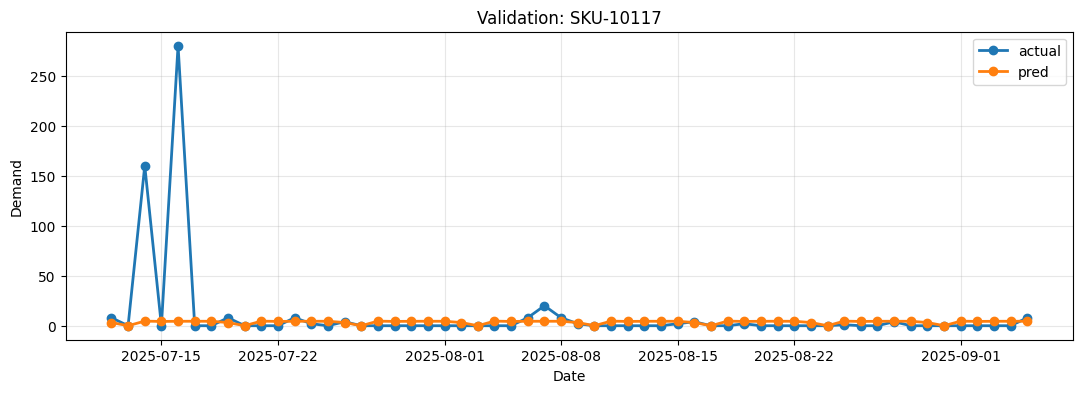

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
14419,SKU-14763,0.001447,1.886477,0.002730,345,484.129623


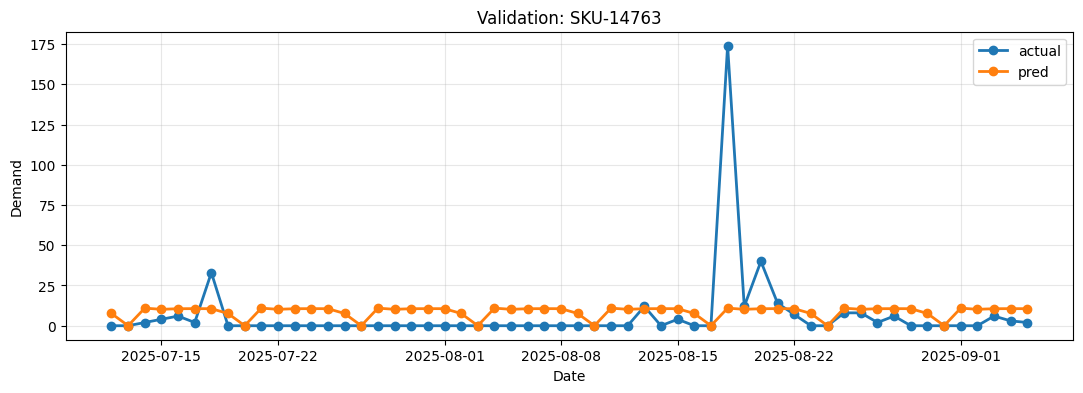

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
3248,SKU-03351,0.001500,1.665578,0.002499,732,4.308942


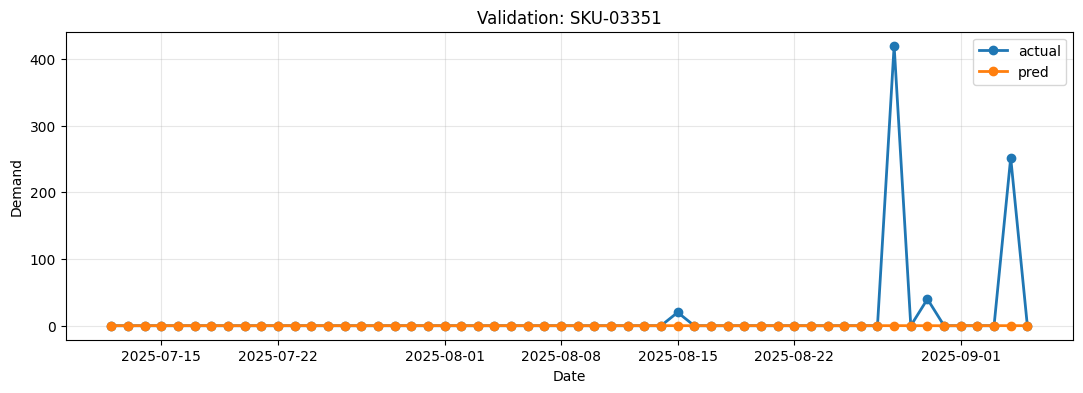

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
2737,SKU-02819,0.001512,1.493602,0.002259,76,89.657089


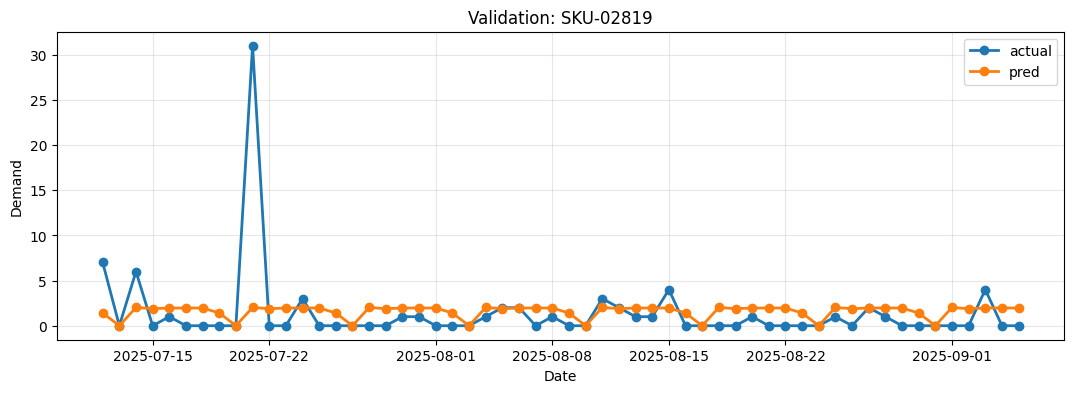

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
14306,SKU-14644,0.001963,1.113950,0.002187,294,152.274456


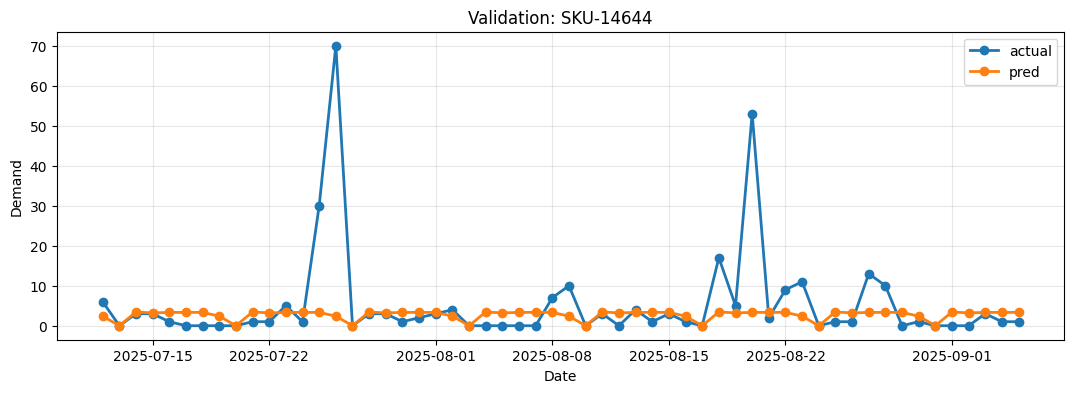

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
1042,SKU-01074,0.000859,2.433596,0.002089,123,6.596679


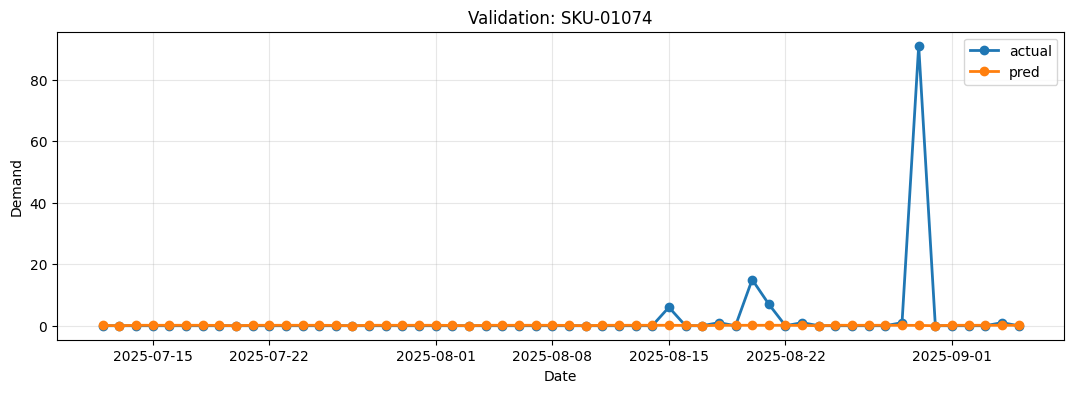

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
13973,SKU-14303,0.002104,0.987564,0.002077,532,260.189021


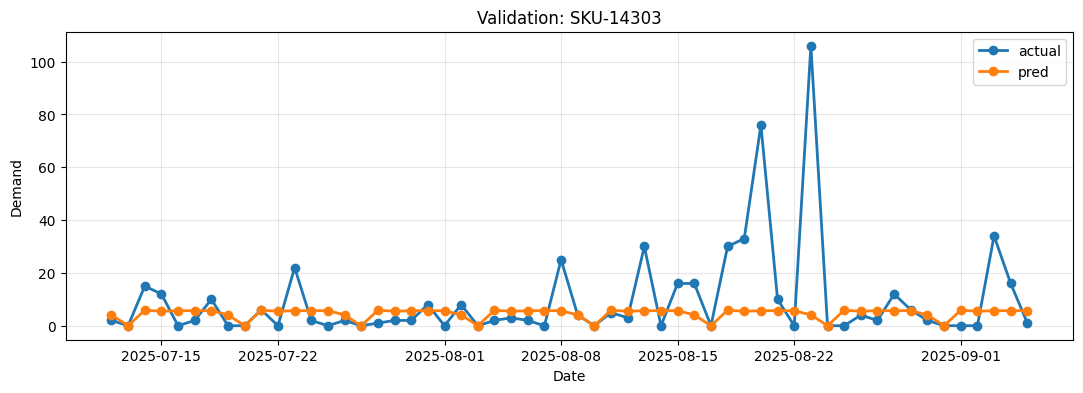

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
9356,SKU-09622,0.001889,1.078082,0.002037,175,64.109949


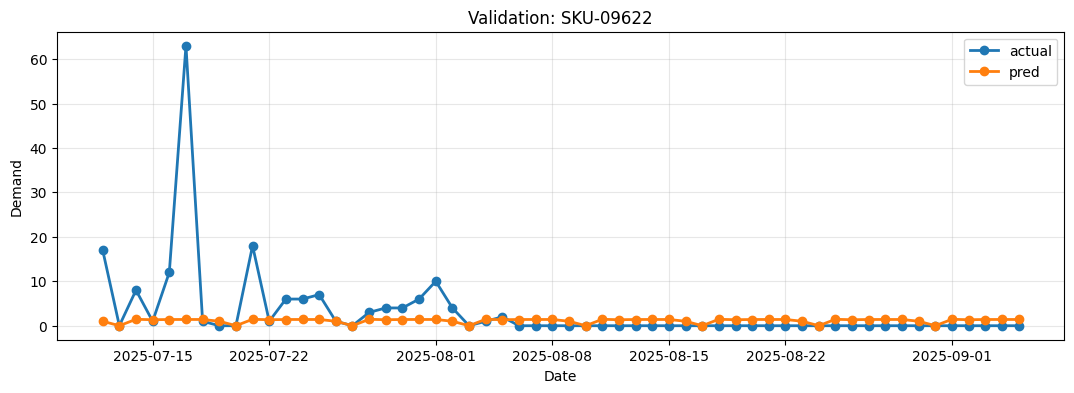

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
14309,SKU-14647,0.001868,1.076999,0.002012,310,297.827851


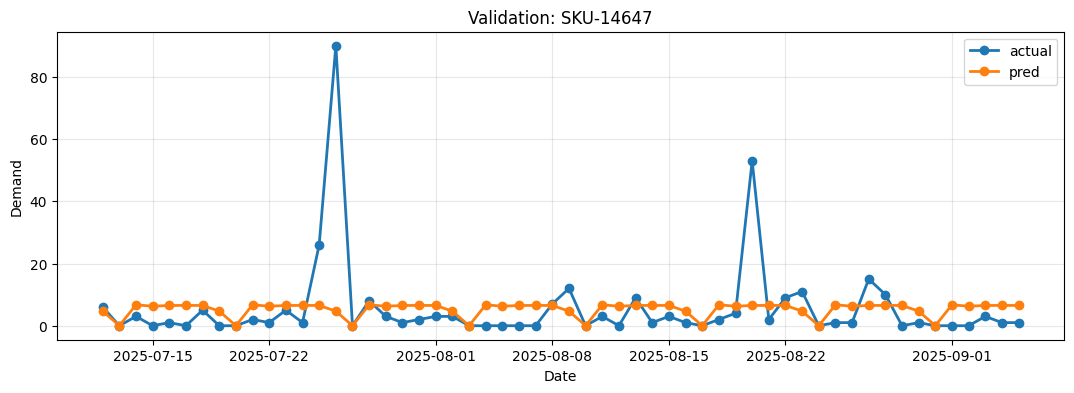

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
12230,SKU-12537,0.006531,0.302239,0.001974,366,791.557086


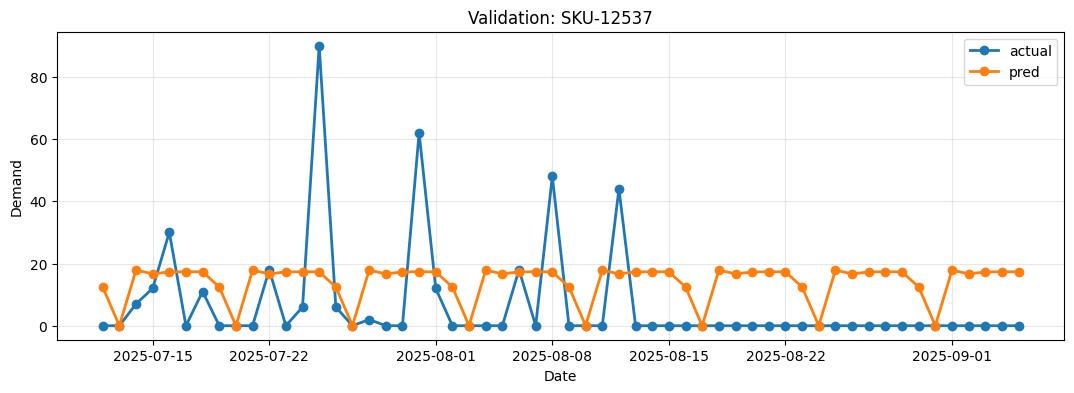

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
6652,SKU-06833,0.000335,5.866109,0.001964,474,161.376541


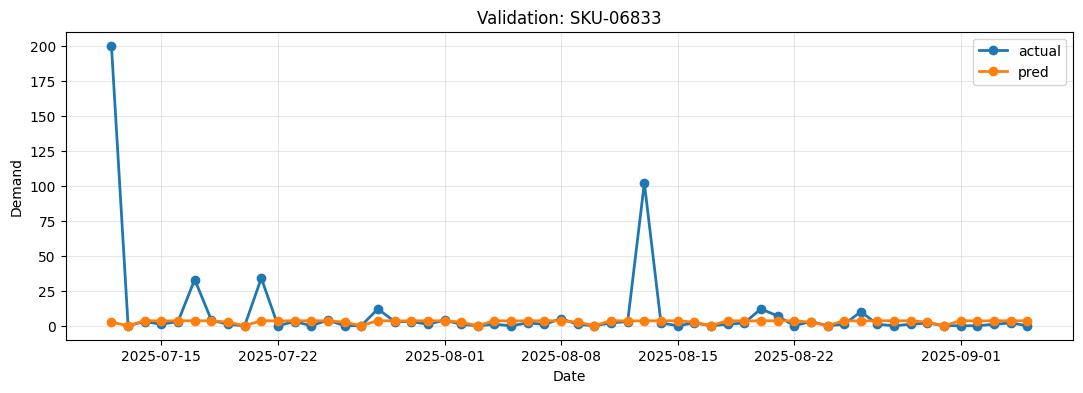

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
336,SKU-00345,0.000897,2.091929,0.001877,370,337.088088


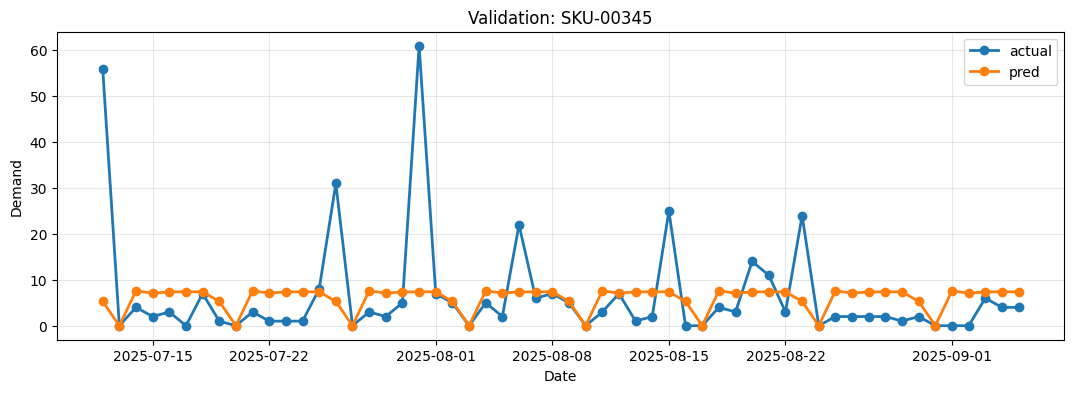

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
4749,SKU-04882,0.002676,0.694895,0.001860,205,284.754432


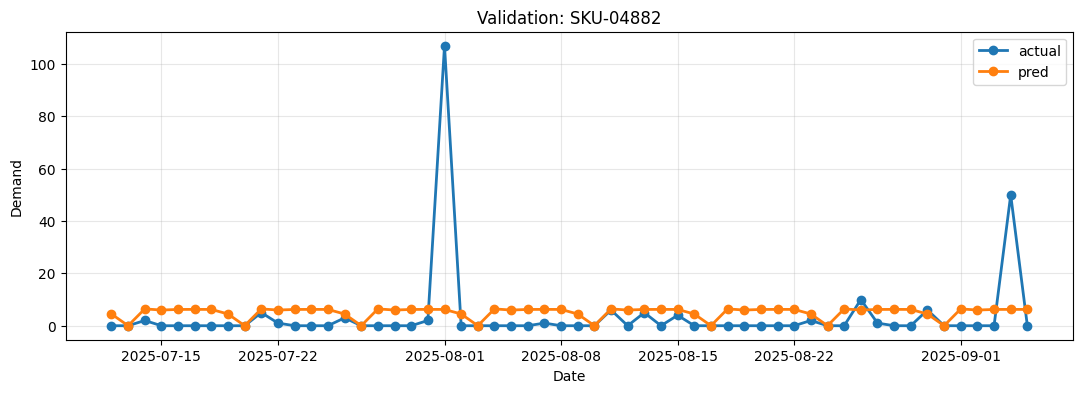

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
6511,SKU-06689,0.000319,5.785402,0.001847,441,159.706271


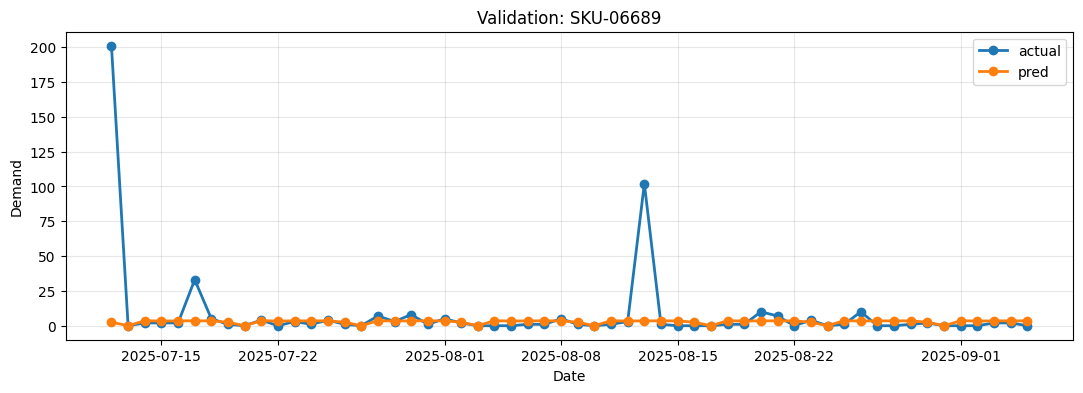

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
14819,SKU-15172,0.001333,1.378145,0.001838,326,257.394872


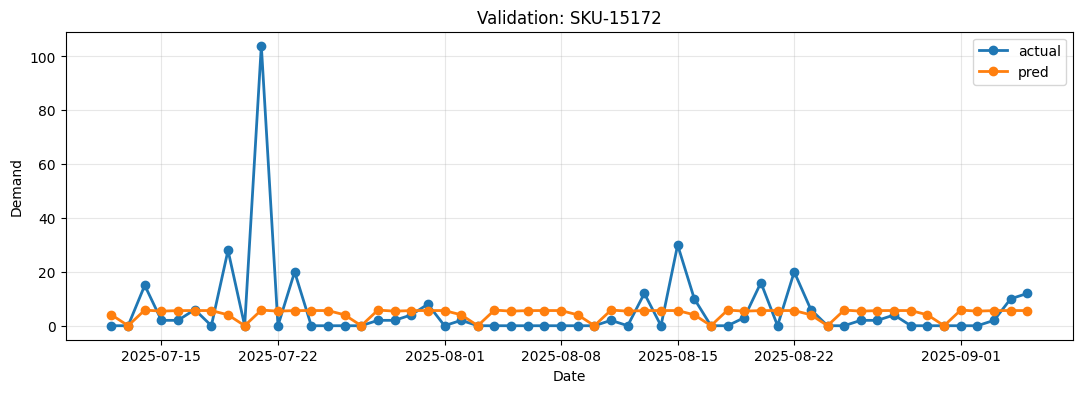

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
5801,SKU-05957,0.001062,1.615431,0.001715,7,0.786271


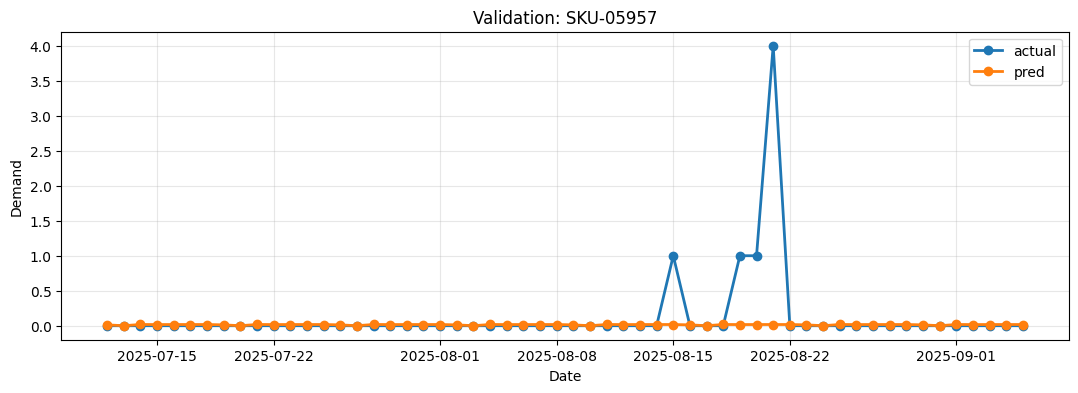

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
4816,SKU-04949,0.000847,1.981385,0.001678,90,25.764808


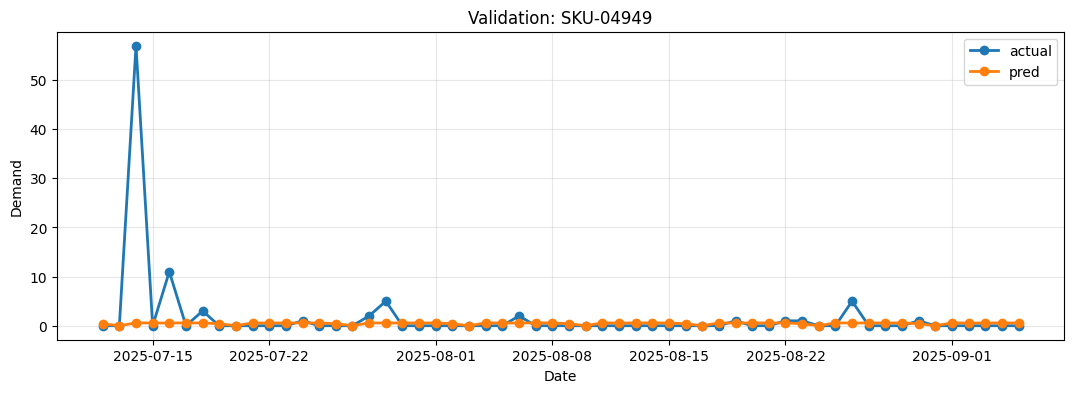

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
12229,SKU-12534,0.007164,0.218845,0.001568,412,940.806398


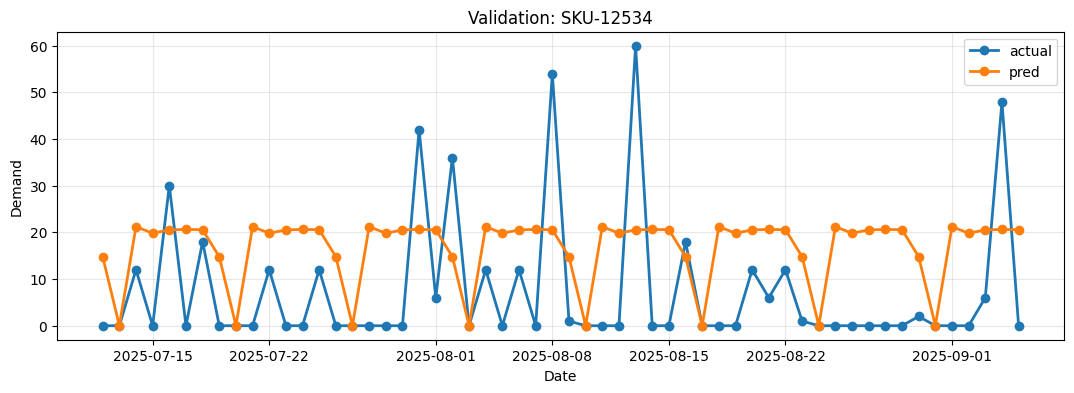

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
9424,SKU-09691,0.001071,1.405816,0.001506,26,0.000000


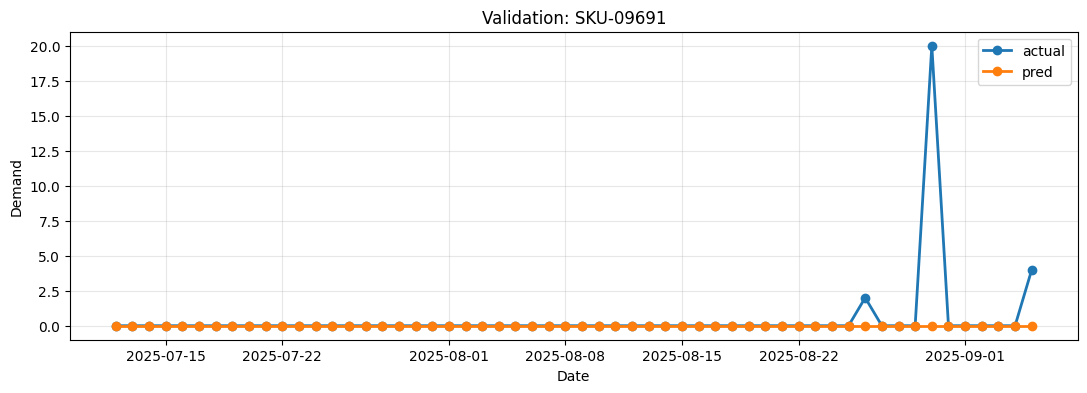

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
364,SKU-00375,0.002078,0.718006,0.001492,25,104.876094


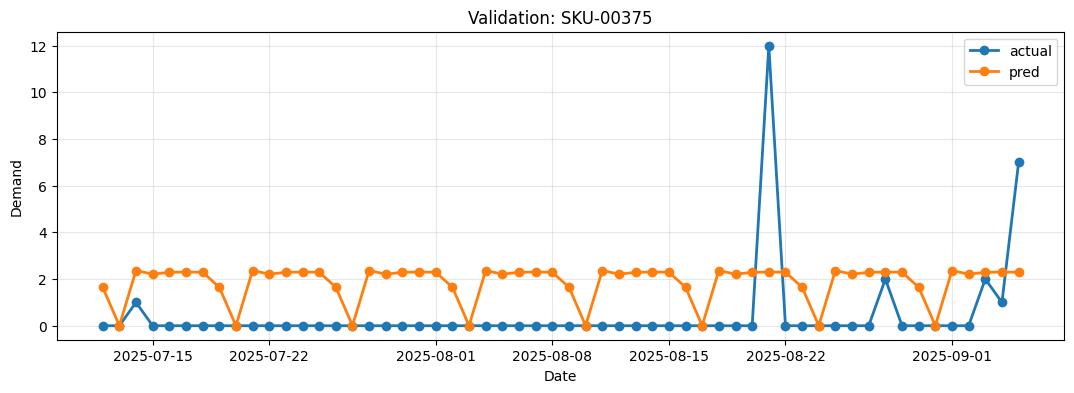

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
15613,SKU-15974,0.001381,1.078402,0.001490,247,345.430555


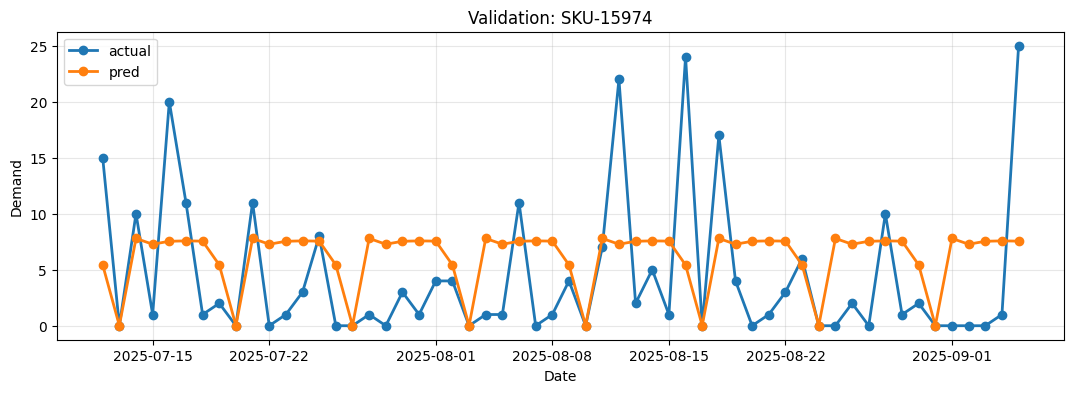

In [35]:
def plot_validation_sku(item_code, eval_df, title_prefix="Validation"):
    tmp = eval_df[eval_df["ItemCode"] == item_code].copy().sort_values("Date")
    if tmp.empty:
        print("No data for", item_code)
        return

    info = (
        baseline_sku_eval[baseline_sku_eval["ItemCode"] == item_code]
        [["ItemCode", "weight", "rmsse", "contribution", "actual_sum", "pred_sum"]]
    )
    display(info)

    plt.figure(figsize=(13, 4))
    plt.plot(tmp["Date"], tmp["actual"], marker="o", label="actual", linewidth=2)
    plt.plot(tmp["Date"], tmp["pred"], marker="o", label="pred", linewidth=2)
    plt.title(f"{title_prefix}: {item_code}")
    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


TOP_ERROR_N = 30
top_error_skus = top_contrib.head(TOP_ERROR_N)["ItemCode"].tolist()
print(top_error_skus)

for sku in top_error_skus:
    plot_validation_sku(sku, baseline_eval_df)

# PHẦN 7 — Tune nhanh baseline rules

Phần này so sánh vài cấu hình baseline:
- Baseline cũ.
- Baseline recent.
- Recent + sparse/inactive rule mạnh.
- Recent + không set weight=0 về 0.

Chọn config tốt nhất theo validation nội bộ.

In [36]:
baseline_configs = [
    {
        "name": "old_windows_28_56_90_180",
        "windows": (28, 56, 90, 180),
        "weights": (0.35, 0.30, 0.20, 0.15),
        "sunday_floor": 0.05,
        "zero_weight_to_zero": False,
        "sparse_penalty": True,
    },
    {
        "name": "recent_14_28_56_90",
        "windows": (14, 28, 56, 90),
        "weights": (0.40, 0.30, 0.20, 0.10),
        "sunday_floor": 0.001,
        "zero_weight_to_zero": True,
        "sparse_penalty": True,
    },
    {
        "name": "recent_more_weight_14",
        "windows": (14, 28, 56, 90),
        "weights": (0.50, 0.25, 0.15, 0.10),
        "sunday_floor": 0.001,
        "zero_weight_to_zero": True,
        "sparse_penalty": True,
    },
    {
        "name": "recent_less_sparse_penalty",
        "windows": (14, 28, 56, 90),
        "weights": (0.40, 0.30, 0.20, 0.10),
        "sunday_floor": 0.001,
        "zero_weight_to_zero": True,
        "sparse_penalty": False,
    },
]

baseline_tune_rows = []

for cfg in baseline_configs:
    pred, base_table, wf = build_baseline_forecast(
        train_part,
        valid_dates,
        sku_list,
        windows=cfg["windows"],
        window_weights=cfg["weights"],
        sunday_floor=cfg["sunday_floor"],
        sparse_penalty=cfg["sparse_penalty"],
        weight_df=weight_part,
        zero_weight_to_zero=cfg["zero_weight_to_zero"]
    )
    score, sku_eval_tmp, eval_tmp = wrmsse_score(actual_valid_long, pred, scale_part, weight_part)
    baseline_tune_rows.append({
        "name": cfg["name"],
        "score": score,
        "windows": cfg["windows"],
        "weights": cfg["weights"],
        "sunday_floor": cfg["sunday_floor"],
        "sparse_penalty": cfg["sparse_penalty"],
        "zero_weight_to_zero": cfg["zero_weight_to_zero"],
    })

baseline_tune = pd.DataFrame(baseline_tune_rows).sort_values("score")
display(baseline_tune)

,name,score,windows,weights,sunday_floor,sparse_penalty,zero_weight_to_zero
1,recent_14_28_56_90,0.574612,"(14, 28, 56, 90)","(0.4, 0.3, 0.2, 0.1)",0.001000,True,True
2,recent_more_weight_14,0.574944,"(14, 28, 56, 90)","(0.5, 0.25, 0.15, 0.1)",0.001000,True,True
3,recent_less_sparse_penalty,0.575929,"(14, 28, 56, 90)","(0.4, 0.3, 0.2, 0.1)",0.001000,False,True
0,old_windows_28_56_90_180,0.576225,"(28, 56, 90, 180)","(0.35, 0.3, 0.2, 0.15)",0.050000,True,False


# PHẦN 8 — Rolling validation cho baseline

Không nên tin một validation split duy nhất.
Phần này tạo 3 folds, mỗi fold forecast 56 ngày.

Ví dụ:
- Fold 1: 56 ngày cuối.
- Fold 2: lùi lại 28 ngày.
- Fold 3: lùi lại thêm 28 ngày.

In [37]:
def make_rolling_folds(transactions, horizon=56, n_folds=3, step_days=28):
    max_date = transactions["Date"].max()
    folds = []
    for i in range(n_folds):
        valid_end = max_date - pd.Timedelta(days=i * step_days)
        valid_start = valid_end - pd.Timedelta(days=horizon - 1)
        train_end = valid_start - pd.Timedelta(days=1)
        folds.append({
            "fold": i + 1,
            "train_end": train_end,
            "valid_start": valid_start,
            "valid_end": valid_end,
            "valid_dates": pd.date_range(valid_start, valid_end, freq="D")
        })
    return folds


def evaluate_baseline_on_fold(transactions, fold, sku_list, cfg=None):
    if cfg is None:
        cfg = {
            "windows": BASELINE_WINDOWS,
            "weights": BASELINE_WEIGHTS,
            "sunday_floor": SUNDAY_FACTOR_FLOOR,
            "sparse_penalty": True,
            "zero_weight_to_zero": True
        }

    train_fold = transactions[transactions["Date"] <= fold["train_end"]].copy()
    valid_fold = transactions[(transactions["Date"] >= fold["valid_start"]) & (transactions["Date"] <= fold["valid_end"])].copy()

    train_daily = aggregate_daily_y(train_fold)
    valid_daily = aggregate_daily_y(valid_fold)
    weight_fold = compute_sku_weights(train_fold)
    train_dates_fold = pd.date_range(train_fold["Date"].min(), train_fold["Date"].max(), freq="D")
    scale_fold = compute_rmsse_scale(train_daily, sku_list, train_dates_fold)
    actual_long = make_actual_matrix_long(valid_daily, sku_list, fold["valid_dates"])

    pred, base_table, wf = build_baseline_forecast(
        train_fold,
        fold["valid_dates"],
        sku_list,
        windows=cfg["windows"],
        window_weights=cfg["weights"],
        sunday_floor=cfg["sunday_floor"],
        sparse_penalty=cfg["sparse_penalty"],
        weight_df=weight_fold,
        zero_weight_to_zero=cfg["zero_weight_to_zero"]
    )

    score, sku_eval, eval_df = wrmsse_score(actual_long, pred, scale_fold, weight_fold)
    return score, sku_eval, eval_df


folds = make_rolling_folds(df, horizon=56, n_folds=3, step_days=28)
display(pd.DataFrame([{k: v for k, v in f.items() if k != "valid_dates"} for f in folds]))

rolling_rows = []
rolling_results = {}

for fold in folds:
    score, sku_eval_fold, eval_df_fold = evaluate_baseline_on_fold(df, fold, sku_list)
    rolling_rows.append({
        "fold": fold["fold"],
        "train_end": fold["train_end"],
        "valid_start": fold["valid_start"],
        "valid_end": fold["valid_end"],
        "baseline_score": score,
    })
    rolling_results[fold["fold"]] = {
        "score": score,
        "sku_eval": sku_eval_fold,
        "eval_df": eval_df_fold,
    }

rolling_baseline = pd.DataFrame(rolling_rows)
display(rolling_baseline)
print("Mean rolling baseline score:", rolling_baseline["baseline_score"].mean())

,fold,train_end,valid_start,valid_end
0,1,2025-07-11,2025-07-12,2025-09-05
1,2,2025-06-13,2025-06-14,2025-08-08
2,3,2025-05-16,2025-05-17,2025-07-11


,fold,train_end,valid_start,valid_end,baseline_score
0,1,2025-07-11,2025-07-12,2025-09-05,0.574612
1,2,2025-06-13,2025-06-14,2025-08-08,0.596342
2,3,2025-05-16,2025-05-17,2025-07-11,0.649845


Mean rolling baseline score: 0.606932981476422


# PHẦN 9 — LightGBM cho top 1000 SKU theo profit weight

Ý tưởng:
- Không train toàn bộ 15,972 SKU ngay.
- Chỉ train LightGBM trên top 1000 SKU có profit weight cao nhất.
- Dự báo theo kiểu recursive 56 ngày:
  - Ngày F1 dùng lịch sử thật.
  - Ngày F2 dùng lịch sử thật + pred F1.
  - ...
- Các SKU ngoài top 1000 vẫn dùng baseline.

Nếu máy chưa có LightGBM:
```bash
pip install lightgbm
```

In [38]:
def get_top_weight_skus(weight_df, top_n=TOP_N_SKUS):
    return (
        weight_df.sort_values("weight", ascending=False)
                 .head(top_n)["ItemCode"]
                 .tolist()
    )


def add_date_features(frame):
    frame = frame.copy()
    frame["dow"] = frame["Date"].dt.dayofweek
    frame["day"] = frame["Date"].dt.day
    frame["month"] = frame["Date"].dt.month
    frame["weekofyear"] = frame["Date"].dt.isocalendar().week.astype(int)
    frame["is_saturday"] = (frame["dow"] == 5).astype(int)
    frame["is_sunday"] = (frame["dow"] == 6).astype(int)
    frame["is_month_start"] = frame["Date"].dt.is_month_start.astype(int)
    frame["is_month_end"] = frame["Date"].dt.is_month_end.astype(int)
    return frame


LAG_FEATURES = [1, 2, 3, 7, 14, 28, 56]
ROLL_WINDOWS = [7, 14, 28, 56, 90]


def make_lgbm_train_frame(transactions, cutoff_date, top_skus, weight_df, scale_df, min_history_days=120):
    """
    Tạo training frame cho LightGBM top SKU.
    Feature lag/rolling dùng shift(1) để không leakage.
    """
    cutoff_date = pd.to_datetime(cutoff_date)
    train_tx = transactions[transactions["Date"] <= cutoff_date].copy()
    daily_sparse = aggregate_daily_y(train_tx)

    train_dates = pd.date_range(train_tx["Date"].min(), cutoff_date, freq="D")
    idx = pd.MultiIndex.from_product([top_skus, train_dates], names=["ItemCode", "Date"])

    g = (
        daily_sparse.set_index(["ItemCode", "Date"])["y"]
        .reindex(idx, fill_value=0)
        .reset_index()
    )

    g = g.sort_values(["ItemCode", "Date"]).reset_index(drop=True)
    g = add_date_features(g)

    # Map SKU -> item_id categorical/int
    item_map = {sku: i for i, sku in enumerate(top_skus)}
    g["item_id"] = g["ItemCode"].map(item_map).astype(int)

    # Lag features
    grp = g.groupby("ItemCode")["y"]
    for lag in LAG_FEATURES:
        g[f"lag_{lag}"] = grp.shift(lag)

    # Rolling features dùng past only: shift(1).rolling()
    shifted = grp.shift(1)
    for w in ROLL_WINDOWS:
        g[f"roll_mean_{w}"] = (
            shifted.groupby(g["ItemCode"])
            .rolling(w, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )
        g[f"roll_sum_{w}"] = (
            shifted.groupby(g["ItemCode"])
            .rolling(w, min_periods=1)
            .sum()
            .reset_index(level=0, drop=True)
        )

    # Static SKU stats tính đến cutoff
    pos_daily = daily_sparse[daily_sparse["y"] > 0].copy()
    static = (
        pos_daily.groupby("ItemCode")
        .agg(
            total_y_pos=("y", "sum"),
            positive_days=("Date", "nunique"),
            last_positive_date=("Date", "max"),
            mean_y_when_sold=("y", "mean"),
            max_y_when_sold=("y", "max")
        )
        .reset_index()
    )

    all_top = pd.DataFrame({"ItemCode": top_skus})
    static = all_top.merge(static, on="ItemCode", how="left")
    static["total_y_pos"] = static["total_y_pos"].fillna(0)
    static["positive_days"] = static["positive_days"].fillna(0)
    static["mean_y_when_sold"] = static["mean_y_when_sold"].fillna(0)
    static["max_y_when_sold"] = static["max_y_when_sold"].fillna(0)
    static["last_positive_date"] = pd.to_datetime(static["last_positive_date"])
    static["days_since_last_sale"] = (cutoff_date - static["last_positive_date"]).dt.days.fillna(9999)
    static["avg_y_per_day"] = static["total_y_pos"] / max(len(train_dates), 1)

    static = static.merge(weight_df[["ItemCode", "weight"]], on="ItemCode", how="left")
    static = static.merge(scale_df[["ItemCode", "scale"]], on="ItemCode", how="left")
    static["weight"] = static["weight"].fillna(0)
    static["scale"] = static["scale"].fillna(EPS).clip(lower=EPS)

    g = g.merge(
        static[[
            "ItemCode", "total_y_pos", "positive_days", "mean_y_when_sold",
            "max_y_when_sold", "days_since_last_sale", "avg_y_per_day",
            "weight", "scale"
        ]],
        on="ItemCode",
        how="left"
    )

    # Bỏ giai đoạn đầu chưa đủ lag
    min_date = train_dates.min() + pd.Timedelta(days=min_history_days)
    g = g[g["Date"] >= min_date].copy()

    # Fill lag missing còn lại
    feature_cols = (
        ["item_id", "dow", "day", "month", "weekofyear", "is_saturday", "is_sunday",
         "is_month_start", "is_month_end"]
        + [f"lag_{l}" for l in LAG_FEATURES]
        + [f"roll_mean_{w}" for w in ROLL_WINDOWS]
        + [f"roll_sum_{w}" for w in ROLL_WINDOWS]
        + ["total_y_pos", "positive_days", "mean_y_when_sold", "max_y_when_sold",
           "days_since_last_sale", "avg_y_per_day", "weight", "scale"]
    )

    for c in feature_cols:
        g[c] = g[c].fillna(0)

    # Sample weight gần với WRMSSE: weight / scale
    g["sample_weight"] = g["weight"] / g["scale"].clip(lower=EPS)
    mean_sw = g["sample_weight"].mean()
    if mean_sw > 0:
        g["sample_weight"] = g["sample_weight"] / mean_sw
    g["sample_weight"] = g["sample_weight"].clip(lower=0.01, upper=100)

    return g, feature_cols, item_map, static


def train_lgbm_model(train_frame, feature_cols):
    if not HAS_LIGHTGBM:
        raise ImportError("LightGBM chưa được cài. Hãy chạy: pip install lightgbm")

    X = train_frame[feature_cols]
    y = train_frame["y"].clip(lower=0)
    sw = train_frame["sample_weight"]

    dtrain = lgb.Dataset(
        X,
        label=y,
        weight=sw,
        categorical_feature=["item_id"],
        free_raw_data=False
    )

    params = {
        "objective": "tweedie",
        "tweedie_variance_power": 1.2,
        "metric": "rmse",
        "learning_rate": 0.03,
        "num_leaves": 63,
        "min_data_in_leaf": 80,
        "feature_fraction": 0.85,
        "bagging_fraction": 0.85,
        "bagging_freq": 1,
        "lambda_l1": 0.1,
        "lambda_l2": 1.0,
        "verbosity": -1,
        "seed": RANDOM_STATE,
        "force_col_wise": True,
    }

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=700
    )

    return model

In [39]:
def build_history_dict(transactions, cutoff_date, top_skus):
    cutoff_date = pd.to_datetime(cutoff_date)
    train_tx = transactions[transactions["Date"] <= cutoff_date].copy()
    daily_sparse = aggregate_daily_y(train_tx)
    train_dates = pd.date_range(train_tx["Date"].min(), cutoff_date, freq="D")

    idx = pd.MultiIndex.from_product([top_skus, train_dates], names=["ItemCode", "Date"])
    hist_df = (
        daily_sparse.set_index(["ItemCode", "Date"])["y"]
        .reindex(idx, fill_value=0)
        .reset_index()
        .sort_values(["ItemCode", "Date"])
    )

    history = {}
    for sku, g in hist_df.groupby("ItemCode"):
        history[sku] = g["y"].to_numpy(dtype=np.float32).tolist()

    return history, train_dates


def get_days_since_last_positive(arr):
    for i, v in enumerate(reversed(arr), start=1):
        if v > 0:
            return i - 1
    return 9999


def make_future_feature_frame_for_date(date, top_skus, history, item_map, static_lookup, feature_cols):
    rows = []
    date = pd.to_datetime(date)

    for sku in top_skus:
        arr = history[sku]
        row = {
            "ItemCode": sku,
            "Date": date,
            "item_id": item_map[sku],
            "dow": date.dayofweek,
            "day": date.day,
            "month": date.month,
            "weekofyear": int(date.isocalendar().week),
            "is_saturday": int(date.dayofweek == 5),
            "is_sunday": int(date.dayofweek == 6),
            "is_month_start": int(date.is_month_start),
            "is_month_end": int(date.is_month_end),
        }

        for lag in LAG_FEATURES:
            row[f"lag_{lag}"] = arr[-lag] if len(arr) >= lag else 0.0

        for w in ROLL_WINDOWS:
            vals = arr[-w:] if len(arr) >= w else arr
            row[f"roll_mean_{w}"] = float(np.mean(vals)) if len(vals) > 0 else 0.0
            row[f"roll_sum_{w}"] = float(np.sum(vals)) if len(vals) > 0 else 0.0

        static_row = static_lookup.get(sku, {})
        for c in ["total_y_pos", "positive_days", "mean_y_when_sold", "max_y_when_sold",
                  "avg_y_per_day", "weight", "scale"]:
            row[c] = static_row.get(c, 0.0)

        # Với future, days_since_last_sale cần update theo history bao gồm prediction trước đó
        row["days_since_last_sale"] = get_days_since_last_positive(arr)

        rows.append(row)

    out = pd.DataFrame(rows)
    for c in feature_cols:
        if c not in out.columns:
            out[c] = 0
        out[c] = out[c].fillna(0)

    return out


def predict_lgbm_recursive(model, transactions, cutoff_date, forecast_dates, top_skus, item_map, static_table, feature_cols):
    history, train_dates = build_history_dict(transactions, cutoff_date, top_skus)

    static_lookup = (
        static_table.set_index("ItemCode")
        .to_dict(orient="index")
    )

    preds = []

    for date in forecast_dates:
        feat = make_future_feature_frame_for_date(
            date,
            top_skus,
            history,
            item_map,
            static_lookup,
            feature_cols
        )

        yhat = model.predict(feat[feature_cols])
        yhat = np.clip(yhat, 0, None)

        day_pred = pd.DataFrame({
            "ItemCode": top_skus,
            "Date": pd.to_datetime(date),
            "pred": yhat
        })
        preds.append(day_pred)

        # Append prediction vào history để forecast recursive
        for sku, pred_val in zip(top_skus, yhat):
            history[sku].append(float(pred_val))

    return pd.concat(preds, ignore_index=True)

# PHẦN 10 — Train LightGBM trên single-fold validation

Phần này:
- Chọn top 1000 SKU theo profit weight trong train fold.
- Train LightGBM.
- Predict 56 ngày validation theo recursive.
- So sánh LightGBM riêng với baseline.

In [40]:
if RUN_LIGHTGBM and HAS_LIGHTGBM:
    top_skus_fold = get_top_weight_skus(weight_part, top_n=TOP_N_SKUS)
    print("Top SKUs for LGBM:", len(top_skus_fold), top_skus_fold[:10])

    lgbm_train_frame, lgbm_feature_cols, item_map, static_table = make_lgbm_train_frame(
        train_part,
        train_part["Date"].max(),
        top_skus_fold,
        weight_part,
        scale_part,
        min_history_days=120
    )

    print("LGBM train frame:", lgbm_train_frame.shape)
    display(lgbm_train_frame.head())
    display(lgbm_train_frame[lgbm_feature_cols + ["y", "sample_weight"]].describe().T.head(30))

    lgbm_model = train_lgbm_model(lgbm_train_frame, lgbm_feature_cols)

    lgbm_valid_pred_top = predict_lgbm_recursive(
        lgbm_model,
        train_part,
        train_part["Date"].max(),
        valid_dates,
        top_skus_fold,
        item_map,
        static_table,
        lgbm_feature_cols
    )

    # LGBM chỉ dự báo top SKUs. Các SKU khác để 0 để xem riêng LGBM score trên toàn metric.
    all_valid_idx = pd.MultiIndex.from_product([sku_list, valid_dates], names=["ItemCode", "Date"])
    lgbm_valid_pred_all = (
        lgbm_valid_pred_top.set_index(["ItemCode", "Date"])["pred"]
        .reindex(all_valid_idx, fill_value=0)
        .reset_index()
    )

    lgbm_score, lgbm_sku_eval, lgbm_eval_df = wrmsse_score(
        actual_valid_long,
        lgbm_valid_pred_all,
        scale_part,
        weight_part
    )

    print("LGBM-only top SKU score, others zero:", lgbm_score)
    display(lgbm_sku_eval.sort_values("contribution", ascending=False).head(30))
else:
    print("Skip LightGBM section.")
    print("RUN_LIGHTGBM =", RUN_LIGHTGBM, "| HAS_LIGHTGBM =", HAS_LIGHTGBM)

Skip LightGBM section.
RUN_LIGHTGBM = True | HAS_LIGHTGBM = False


# PHẦN 11 — Blend baseline + LightGBM

Vì LightGBM chỉ train top 1000 SKU, ta blend như sau:

```text
final_pred = baseline_pred
final_pred[top_1000] = alpha × LightGBM + (1-alpha) × baseline
```

Sau đó chọn alpha tốt nhất theo validation.

In [41]:
def blend_baseline_lgbm(baseline_pred, lgbm_pred_top, top_skus, alpha):
    out = baseline_pred.copy()
    key_cols = ["ItemCode", "Date"]

    lgb = lgbm_pred_top.copy()
    lgb = lgb.rename(columns={"pred": "lgbm_pred"})

    out = out.merge(lgb[key_cols + ["lgbm_pred"]], on=key_cols, how="left")
    mask = out["ItemCode"].isin(top_skus) & out["lgbm_pred"].notna()
    out.loc[mask, "pred"] = (
        alpha * out.loc[mask, "lgbm_pred"] +
        (1 - alpha) * out.loc[mask, "pred"]
    )
    out["pred"] = out["pred"].clip(lower=0)
    return out[key_cols + ["pred"]]


if RUN_LIGHTGBM and HAS_LIGHTGBM and "lgbm_valid_pred_top" in globals():
    alpha_rows = []
    blend_results = {}

    for alpha in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        blend_pred = blend_baseline_lgbm(
            baseline_valid_pred,
            lgbm_valid_pred_top,
            top_skus_fold,
            alpha=alpha
        )
        score, sku_eval_blend, eval_df_blend = wrmsse_score(
            actual_valid_long,
            blend_pred,
            scale_part,
            weight_part
        )
        alpha_rows.append({"alpha_lgbm": alpha, "blend_score": score})
        blend_results[alpha] = {
            "pred": blend_pred,
            "score": score,
            "sku_eval": sku_eval_blend,
            "eval_df": eval_df_blend,
        }

    alpha_table = pd.DataFrame(alpha_rows).sort_values("blend_score")
    display(alpha_table)

    BEST_ALPHA = float(alpha_table.iloc[0]["alpha_lgbm"])
    best_blend = blend_results[BEST_ALPHA]
    print("BEST_ALPHA:", BEST_ALPHA)
    print("Best blend score:", best_blend["score"])

    display(best_blend["sku_eval"].sort_values("contribution", ascending=False).head(30))
else:
    BEST_ALPHA = 0.5
    print("Skip blend because LightGBM predictions are not available.")

Skip blend because LightGBM predictions are not available.


# PHẦN 12 — Rolling validation cho LightGBM + blend

Mặc định `RUN_LIGHTGBM_ROLLING = False` vì phần này có thể mất thời gian.
Khi cần kiểm tra chắc hơn, bật lên ở phần config.

In [42]:
def evaluate_lgbm_blend_on_fold(transactions, fold, sku_list, alpha=0.5, top_n=TOP_N_SKUS):
    train_fold = transactions[transactions["Date"] <= fold["train_end"]].copy()
    valid_fold = transactions[(transactions["Date"] >= fold["valid_start"]) & (transactions["Date"] <= fold["valid_end"])].copy()

    train_daily = aggregate_daily_y(train_fold)
    valid_daily = aggregate_daily_y(valid_fold)
    weight_fold = compute_sku_weights(train_fold)
    train_dates_fold = pd.date_range(train_fold["Date"].min(), train_fold["Date"].max(), freq="D")
    scale_fold = compute_rmsse_scale(train_daily, sku_list, train_dates_fold)
    actual_long = make_actual_matrix_long(valid_daily, sku_list, fold["valid_dates"])

    baseline_pred, base_table, wf = build_baseline_forecast(
        train_fold,
        fold["valid_dates"],
        sku_list,
        weight_df=weight_fold,
        zero_weight_to_zero=True
    )
    baseline_score, _, _ = wrmsse_score(actual_long, baseline_pred, scale_fold, weight_fold)

    top_skus = get_top_weight_skus(weight_fold, top_n=top_n)
    train_frame, feature_cols, item_map_fold, static_table_fold = make_lgbm_train_frame(
        train_fold,
        train_fold["Date"].max(),
        top_skus,
        weight_fold,
        scale_fold,
        min_history_days=120
    )
    model = train_lgbm_model(train_frame, feature_cols)
    lgbm_pred_top = predict_lgbm_recursive(
        model,
        train_fold,
        train_fold["Date"].max(),
        fold["valid_dates"],
        top_skus,
        item_map_fold,
        static_table_fold,
        feature_cols
    )

    blend_pred = blend_baseline_lgbm(baseline_pred, lgbm_pred_top, top_skus, alpha=alpha)
    blend_score, sku_eval_blend, eval_df_blend = wrmsse_score(actual_long, blend_pred, scale_fold, weight_fold)

    return {
        "baseline_score": baseline_score,
        "blend_score": blend_score,
        "sku_eval": sku_eval_blend,
        "eval_df": eval_df_blend
    }


if RUN_LIGHTGBM_ROLLING and HAS_LIGHTGBM:
    rolling_lgbm_rows = []
    for fold in folds:
        res = evaluate_lgbm_blend_on_fold(
            df,
            fold,
            sku_list,
            alpha=BEST_ALPHA,
            top_n=TOP_N_SKUS
        )
        rolling_lgbm_rows.append({
            "fold": fold["fold"],
            "train_end": fold["train_end"],
            "valid_start": fold["valid_start"],
            "valid_end": fold["valid_end"],
            "baseline_score": res["baseline_score"],
            "blend_score": res["blend_score"],
        })

    rolling_lgbm = pd.DataFrame(rolling_lgbm_rows)
    display(rolling_lgbm)
    print("Mean baseline:", rolling_lgbm["baseline_score"].mean())
    print("Mean blend:", rolling_lgbm["blend_score"].mean())
else:
    print("Skip rolling LightGBM.")
    print("RUN_LIGHTGBM_ROLLING =", RUN_LIGHTGBM_ROLLING, "| HAS_LIGHTGBM =", HAS_LIGHTGBM)

Skip rolling LightGBM.
RUN_LIGHTGBM_ROLLING = True | HAS_LIGHTGBM = False


# PHẦN 13 — Final training & tạo submission

Phần này:
1. Train baseline trên toàn bộ train.
2. Nếu có LightGBM, train top 1000 trên toàn bộ train.
3. Blend với alpha tốt nhất từ validation.
4. Convert về đúng format `sample_submission.csv`.

Nếu chưa có `sample_submission.csv`, phần này sẽ bỏ qua.

In [43]:
def make_submission_from_long_pred(sample_sub, pred_long):
    sub = sample_sub.copy()
    fcols = [c for c in sub.columns if c.startswith("F")]

    sub["window"] = sub["id"].str.extract(r"_(validation|evaluation)$")[0]
    sub["ItemCode"] = sub["id"].str.replace(r"_(validation|evaluation)$", "", regex=True)

    date_map = {
        "validation": pd.date_range("2025-09-06", periods=28, freq="D"),
        "evaluation": pd.date_range("2025-10-04", periods=28, freq="D")
    }

    pred_lookup = pred_long.set_index(["ItemCode", "Date"])["pred"]

    for idx, row in sub.iterrows():
        dates = date_map[row["window"]]
        item = row["ItemCode"]
        vals = [float(pred_lookup.get((item, d), 0.0)) for d in dates]
        sub.loc[idx, fcols] = vals

    sub = sub[sample_sub.columns]

    assert sub["id"].is_unique, "Duplicate id detected!"
    assert set(sub["id"]) == set(sample_sub["id"]), "Submission id set mismatch!"
    assert sub.shape == sample_sub.shape, "Submission shape mismatch!"
    assert np.isfinite(sub[fcols].to_numpy()).all(), "NaN/Inf predictions detected!"
    assert (sub[fcols].to_numpy() >= 0).all(), "Negative predictions detected!"

    return sub

In [44]:
if SAMPLE_PATH.exists():
    sample_sub = pd.read_csv(SAMPLE_PATH)
    display(sample_sub.head())
    print("Sample submission shape:", sample_sub.shape)

    forecast_dates_56 = pd.date_range("2025-09-06", periods=56, freq="D")

    full_weight_df = compute_sku_weights(df)

    final_baseline_pred, final_base_table, final_weekday_factor = build_baseline_forecast(
        df,
        forecast_dates_56,
        sku_list,
        windows=BASELINE_WINDOWS,
        window_weights=BASELINE_WEIGHTS,
        sunday_floor=SUNDAY_FACTOR_FLOOR,
        weight_df=full_weight_df,
        zero_weight_to_zero=True
    )

    final_pred = final_baseline_pred.copy()
    final_name = OUTPUT_DIR / "submission_baseline_improved.csv"

    if RUN_LIGHTGBM and HAS_LIGHTGBM:
        print("Training final LightGBM on full train...")

        full_daily = aggregate_daily_y(df)
        full_dates = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
        full_scale_df = compute_rmsse_scale(full_daily, sku_list, full_dates)
        top_skus_full = get_top_weight_skus(full_weight_df, top_n=TOP_N_SKUS)

        final_lgbm_train_frame, final_feature_cols, final_item_map, final_static_table = make_lgbm_train_frame(
            df,
            df["Date"].max(),
            top_skus_full,
            full_weight_df,
            full_scale_df,
            min_history_days=120
        )

        final_lgbm_model = train_lgbm_model(final_lgbm_train_frame, final_feature_cols)

        final_lgbm_pred_top = predict_lgbm_recursive(
            final_lgbm_model,
            df,
            df["Date"].max(),
            forecast_dates_56,
            top_skus_full,
            final_item_map,
            final_static_table,
            final_feature_cols
        )

        final_pred = blend_baseline_lgbm(
            final_baseline_pred,
            final_lgbm_pred_top,
            top_skus_full,
            alpha=BEST_ALPHA
        )
        final_name = OUTPUT_DIR / f"submission_blend_lgbm_alpha_{BEST_ALPHA:.2f}.csv"

    submission = make_submission_from_long_pred(sample_sub, final_pred)
    submission.to_csv(final_name, index=False)

    print("Saved:", final_name)
    display(submission.head())
    display(submission.tail())

    fcols = [c for c in submission.columns if c.startswith("F")]
    print("Duplicate id:", submission["id"].duplicated().sum())
    print("NaN count:", submission[fcols].isna().sum().sum())
    print("Negative count:", (submission[fcols] < 0).sum().sum())
    display(submission[fcols].describe().T.head())
else:
    print("Không tìm thấy sample_submission.csv nên bỏ qua tạo submission.")
    print("Hãy đặt sample_submission.csv cùng thư mục notebook để tạo file nộp.")

,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,SKU-00001_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,SKU-00002_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,SKU-00003_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,SKU-00004_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,SKU-00005_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Sample submission shape: (31944, 29)
Saved: c:\Homework\Code File\Python Code File\giải cỏ\main\output\submission_baseline_improved.csv


,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,SKU-00001_validation,0.208610,0.000369,0.294006,0.273203,0.286345,0.287715,0.285628,0.208610,0.000369,0.294006,0.273203,0.286345,0.287715,0.285628,0.208610,0.000369,0.294006,0.273203,0.286345,0.287715,0.285628,0.208610,0.000369,0.294006,0.273203,0.286345,0.287715,0.285628
1,SKU-00002_validation,3.633747,0.006427,5.121247,4.758895,4.987815,5.011670,4.975315,3.633747,0.006427,5.121247,4.758895,4.987815,5.011670,4.975315,3.633747,0.006427,5.121247,4.758895,4.987815,5.011670,4.975315,3.633747,0.006427,5.121247,4.758895,4.987815,5.011670,4.975315
2,SKU-00003_validation,10.848557,0.019189,15.289491,14.207690,14.891131,14.962349,14.853812,10.848557,0.019189,15.289491,14.207690,14.891131,14.962349,14.853812,10.848557,0.019189,15.289491,14.207690,14.891131,14.962349,14.853812,10.848557,0.019189,15.289491,14.207690,14.891131,14.962349,14.853812
3,SKU-00004_validation,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,SKU-00005_validation,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
31939,SKU-16329_evaluation,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
31940,SKU-16330_evaluation,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
31941,SKU-16331_evaluation,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
31942,SKU-16332_evaluation,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
31943,SKU-16333_evaluation,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Duplicate id: 0
NaN count: 0
Negative count: 0


,count,mean,std,min,25%,50%,75%,max
F1,"31,944.000000",0.068793,0.894254,0.000000,0.000000,0.000000,0.003133,75.963977
F2,"31,944.000000",0.000122,0.001582,0.000000,0.000000,0.000000,0.000006,0.134362
F3,"31,944.000000",0.096955,1.260323,0.000000,0.000000,0.000000,0.004416,107.060368
F4,"31,944.000000",0.090095,1.171150,0.000000,0.000000,0.000000,0.004104,99.485357
F5,"31,944.000000",0.094428,1.227486,0.000000,0.000000,0.000000,0.004301,104.270964


# PHẦN 14 — Checklist & hướng cải thiện tiếp

Checklist trước khi submit:
- File có đúng số dòng bằng `sample_submission.csv`.
- Không thiếu `id`.
- Không duplicate `id`.
- Các cột `F1` → `F28` đều là số.
- Không có giá trị âm.
- Không có NaN.
- Không round nếu không cần, metric chấm float trực tiếp.

Hướng cải thiện tiếp:
1. Tune `BASELINE_WINDOWS`, `BASELINE_WEIGHTS`.
2. Tune sparse/recency rules.
3. Tune `TOP_N_SKUS`: 500, 1000, 2000.
4. Tune LightGBM objective: `tweedie`, `poisson`, `regression`.
5. Tune blend alpha theo rolling validation.
6. Xử lý riêng top 30 SKU contribution cao nhất bằng rule thủ công nếu thấy pattern rõ.